# Comparación de LSTM Y CNN

En este documento se planea realizar una comparacion entre distintas formas de las arquitecturas LSTM y CNN dado que fueron las que destacaron en las comparaciones.

## LSTM CANDIDATAS
* LSTM variando:
    * profundidades
    * learning rates
    * funcion de activacionm
* XLSTM (DISPONIBLE EN EL SIGUIENTE [ENLACE](https://www.researchgate.net/publication/383976780_A_Comparative_Analysis_of_Machine_Learning_and_Deep_Learning_Techniques_for_Accurate_Market_Price_Forecasting))
* LSTM con celdas GRU
* LSTM hibridas con celdas RNN (dado que [aca](https://arxiv.org/pdf/1503.04069) se indica que tienen potencial )

CNN CANDIDADTAS

* Fuzzy CNN, [disponible aca](https://arxiv.org/abs/2406.03506 )


# Declaración de librerías


In [2]:
# LIBRERIAS
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Reshape, Input
from tensorflow.keras.models import Sequential
import keras_tuner as kt

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from sklearn.metrics import precision_recall_fscore_support
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
import wandb


2026-07-07 19:23:12.882913: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-07 19:23:12.883017: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-07 19:23:12.884682: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-07 19:23:12.895651: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-07 19:23:14.054083: W tensorflow/compiler/tf2

In [3]:
import keras_tuner as kt
# métrica F1 macro compatible con multiclase
class F1MacroScore(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.true_positives  = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros')
        self.false_positives = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_classes = tf.argmax(y_pred, axis=1)
        y_true_flat    = tf.cast(tf.reshape(y_true, [-1]), tf.int64)

        # one-hot encoding vectorizado — sin loops
        y_true_oh = tf.one_hot(y_true_flat,    self.num_classes)  # (batch, num_classes)
        y_pred_oh = tf.one_hot(y_pred_classes, self.num_classes)  # (batch, num_classes)

        self.true_positives.assign_add(
            tf.reduce_sum(y_true_oh * y_pred_oh, axis=0)
        )
        self.false_positives.assign_add(
            tf.reduce_sum((1 - y_true_oh) * y_pred_oh, axis=0)
        )
        self.false_negatives.assign_add(
            tf.reduce_sum(y_true_oh * (1 - y_pred_oh), axis=0)
        )

    def result(self):
        precision    = self.true_positives / (self.true_positives + self.false_positives + 1e-7)
        recall       = self.true_positives / (self.true_positives + self.false_negatives + 1e-7)
        f1_per_class = 2 * precision * recall / (precision + recall + 1e-7)
        return tf.reduce_mean(f1_per_class)

    def reset_state(self):
        for var in self.variables:
            var.assign(tf.zeros_like(var))

class SparseRecallMacro(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='recall_macro', **kwargs):
        super(SparseRecallMacro, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        # Usamos la métrica estándar internamente para cada clase de forma binaria
        self.recall_fn = tf.keras.metrics.Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        # 1. Convertir las probabilidades de y_pred a la clase con mayor valor (0, 1, 2, 3...)
        y_pred_converted = tf.argmax(y_pred, axis=-1)
        
        # 2. Llevar ambas variables a One-Hot para poder calcular el Recall correctamente
        y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=self.num_classes)
        y_pred_one_hot = tf.one_hot(tf.cast(y_pred_converted, tf.int32), depth=self.num_classes)
        
        # Asegurar dimensiones limpias (None, num_classes)
        y_true_one_hot = tf.reshape(y_true_one_hot, [-1, self.num_classes])
        y_pred_one_hot = tf.reshape(y_pred_one_hot, [-1, self.num_classes])

        # 3. Actualizar la métrica interna
        self.recall_fn.update_state(y_true_one_hot, y_pred_one_hot, sample_weight)

    def result(self):
        return self.recall_fn.result()

    def reset_states(self):
        self.recall_fn.reset_states()

In [4]:
# Carpeta de artefactos, modelos y resultados
dir_artifacts = "artefactos/artefactos_train_arq_v1"

# crear carpeta si no existe
import os
os.makedirs(dir_artifacts, exist_ok=True)

umbral_shap = 0


In [5]:

def mostrar_grafica_agrupada(df, metrica, columna_salud, columna_canal, colores_salud, guardar_figura=False, nombre_figura="grafica_agrupada.png", titulo_grafica="Grafica agrupada"):
    """
    Genera subplots verticales, uno para cada canal, mostrando la evolución de una métrica
    utilizando los nombres de archivo/timestamps en el eje X.
    """
    # Identificar los canales únicos y ordenarlos
    canales = sorted(df[columna_canal].unique())
    num_canales = len(canales)


    # Crear la figura con subplots compartiendo el eje X
    fig, axs = plt.subplots(num_canales, 1, figsize=(13, 3 * num_canales), sharex=True)
    
    # Si solo hay un canal, axs no es una lista, lo convertimos para poder usar índices
    if num_canales == 1:
        axs = [axs]

    # Variable para almacenar el df_canal del último canal y usarlo para los ticks
    df_ultimo_canal = None

    labels_salud_observados = set()
    
    for i, canal in enumerate(canales):
        # Filtrar datos para el canal actual
        df_canal = df[df[columna_canal] == canal].reset_index(drop=True)
        df_ultimo_canal = df_canal # Guardamos referencia para los labels finales
        ax = axs[i]
        
        

        # Dibujar segmentos por color según el estado de salud
        for j in range(len(df_canal) - 1):
            estado = df_canal.iloc[j][columna_salud]
            color = colores_salud.get(estado, 'gray')
            
            label = estado if estado not in labels_salud_observados else "_nolegend_"
            labels_salud_observados.add(estado)
            
            # Graficar segmento
            ax.plot([j, j+1], 
                    [df_canal.iloc[j][metrica], df_canal.iloc[j+1][metrica]], 
                    color=color, 
                    label=label,
                    linewidth=1.5)

        # Configuración de cada subplot
        ax.set_title(f'Análisis de {metrica} - {canal}', fontweight='bold', fontsize=10)
        ax.set_ylabel(metrica, fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.5)

    # --- Configuración de los Timestamps en el último eje ---
    if df_ultimo_canal is not None:
        import numpy as np  # Por si no lo has importado arriba
        
        # Generamos exactamente 12 índices distribuidos uniformemente del 0 al final
        # Usamos astype(int) para obtener posiciones válidas en el dataframe
        num_etiquetas = 12
        tick_idx = np.linspace(0, len(df_ultimo_canal) - 1, num_etiquetas).astype(int)
        
        # Eliminamos duplicados por si el DataFrame es extremadamente corto
        tick_idx = sorted(list(set(tick_idx)))
            
        tick_labels = [df_ultimo_canal.loc[idx, 'archivo'] for idx in tick_idx]

        axs[-1].set_xticks(tick_idx)
        axs[-1].set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
        axs[-1].set_xlabel("Timestamp / Archivo", fontsize=10)

    # --- Crear una leyenda única para toda la figura (recolectando de todos los ejes) ---
    by_label = {}
    
    for ax in axs:
        handles, labels = ax.get_legend_handles_labels()
        by_label.update(zip(labels, handles))
    
    # Crear la leyenda global con los datos unificados
    fig.legend(by_label.values(), by_label.keys(), loc='center left', 
               bbox_to_anchor=(0.85, 0.95), title="Estado de Salud")

    fig.suptitle(titulo_grafica, fontweight='bold', fontsize=12)
    plt.tight_layout(rect=[0, 0, 0.85, 0.98])
    
    # Guardar figura si se indicó
    if guardar_figura:
        fig.savefig(nombre_figura, dpi=300, bbox_inches='tight')
        print(f"Figura guardada como: {nombre_figura}")
    
    plt.show()

# --- Ejemplo de cómo llamar a la función ---
COLORES_ETIQUETA = {
    "Normal":                  "#2ecc71",
    "Early":                   "#3498db",
    "Suspect":                 "#f1c40f",
    "Inner race failure":      "#e67e22",
    "Rolling element failure": "#e74c3c",
    "Stage 2 failure":         "#9b59b6",
    "Inminent failure":        "#c0392b",
}


In [6]:
# limpieza de dataset, se aplicacran los pasos para crear matriz de tensores 
# y otras cosas vistas para elaborar el dataset de entrenamiento

def obtener_tensores_de_DF(df, separar_train_test=True, test_size=0.2, random_state=42, data_aumentation=False):

    df_copy = df.copy()
    df_copy["canal"] = df_copy["canal"].str.extract(r'(\d+)').astype(int)
    features = df_copy.columns.drop(["archivo", "canal", "salud_miltos", "salud"])

    experimentos = df_copy["archivo"].unique()
    X = []
    y = []
    for exp in experimentos:
        
        bloque = df_copy[df_copy["archivo"] == exp].sort_values("canal")
        matriz = bloque[features].values
        X.append(matriz)
        y.append(bloque["salud_miltos"].iloc[0])

    # Codificación de clases 
    le = LabelEncoder()
    y = le.fit_transform(y)

    # Declaracion de nombre adecuados
    X_train = np.array(X)
    y_train = np.array(y)


    # Separación sobre el 100% de los datos en Train (80%) y Test (test_size%) 
    if separar_train_test:
        X_train_temp, X_test, y_train_temp, y_test = train_test_split(
            X_train, y_train, test_size=test_size, random_state=random_state, stratify=y
        )
        # Separación de Train en Train (87.5%) y Validación (12.5%) para obtener un 10% del total de datos para validación
        X_train, X_valid, y_train, y_valid = train_test_split(
            X_train_temp, y_train_temp, test_size=0.125, random_state=random_state, stratify=y_train_temp
        )
    
    # Estandarización de features 
    scaler = StandardScaler()

    X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
    X_train_scaled = scaler.fit_transform(X_train_reshaped)
    X_train = X_train_scaled.reshape(X_train.shape)

    if separar_train_test:
        # Para Test
        X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])
        X_test_scaled = scaler.transform(X_test_reshaped) 
        X_test = X_test_scaled.reshape(X_test.shape)

        # Para Valid
        X_valid_reshaped = X_valid.reshape(-1, X_valid.shape[-1])
        X_valid_scaled = scaler.transform(X_valid_reshaped) 
        X_valid = X_valid_scaled.reshape(X_valid.shape)
    
    if data_aumentation:
        def add_noise(X, noise_level=0.01):
            noise = np.random.normal(0, noise_level, X.shape)
            return X + noise

        def scaling(X, sigma=0.1):
            factor = np.random.normal(1.0, sigma, (X.shape[0], 1, 1))
            return X * factor

        def time_shift(X, shift_max=5):
            X_shifted = np.zeros_like(X)
            for i in range(X.shape[0]):
                shift = np.random.randint(-shift_max, shift_max)
                X_shifted[i] = np.roll(X[i], shift, axis=0)
            return X_shifted

        # ---------- IDENTIFICAR CLASE MINORITARIA ----------
        classes, counts = np.unique(y_train, return_counts=True)
        minority_class = classes[np.argmin(counts)]

        # ---------- EXTRAER CLASE MINORITARIA ----------
        X_min = X_train[y_train == minority_class]

        # ---------- GENERAR DATOS AUMENTADOS ----------
        X_aug = add_noise(X_min)
        X_aug = np.concatenate([
            X_aug,
            scaling(X_min),
            time_shift(X_min)
        ])

        y_aug = np.full(len(X_aug), minority_class)

        # ---------- COMBINAR DATASET ----------
        X_train = np.concatenate([X_train, X_aug])
        y_train = np.concatenate([y_train, y_aug])

        # ---------- CALCULAR CLASS WEIGHT ----------
        weights = compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train),
            y=y_train
        )

        class_weight = dict(zip(np.unique(y_train), weights))

    if separar_train_test:
        return X_train, y_train, X_valid, y_valid, X_test, y_test
    else:
        return X_train, y_train


In [7]:
# 1. Definimos la capa personalizada compatible con KerasTuner
class FuzzyMembershipLayer(tf.keras.layers.Layer):
    def __init__(self, num_fuzzy_sets=3, **kwargs):
        super(FuzzyMembershipLayer, self).__init__(**kwargs)
        self.num_fuzzy_sets = num_fuzzy_sets

    def build(self, input_shape):
        num_features = input_shape[-1]
        self.mu = self.add_weight(
            name='mu',
            shape=(num_features, self.num_fuzzy_sets),
            initializer='random_normal',
            trainable=True
        )
        self.sigma = self.add_weight(
            name='sigma',
            shape=(num_features, self.num_fuzzy_sets),
            initializer='ones',
            trainable=True
        )

    def call(self, inputs):
        inputs_expanded = tf.expand_dims(inputs, axis=-1)
        numerator = tf.square(inputs_expanded - self.mu)
        denominator = 2.0 * tf.square(self.sigma) + 1e-5
        return tf.exp(-numerator / denominator)

    def get_config(self):
        config = super(FuzzyMembershipLayer, self).get_config()
        config.update({"num_fuzzy_sets": self.num_fuzzy_sets})
        return config

In [73]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Layer, Dropout, Dense

# 1. Definición matemática simplificada de una Celda xLSTM estable (Exponential Gating)
class XLSTMCell(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super(XLSTMCell, self).__init__(**kwargs)
        self.units = units
        self.state_size = [units, units] # Estado oculto (h) y Estado de celda (c)

    def build(self, input_shape):
        input_dim = input_shape[-1]
        
        # Pesos de las compuertas tradicionales y exponenciales
        self.W = self.add_weight(shape=(input_dim, self.units * 4), initializer='glorot_uniform', name='W')
        self.U = self.add_weight(shape=(self.units, self.units * 4), initializer='orthogonal', name='U')
        self.b = self.add_weight(shape=(self.units * 4,), initializer='zeros', name='b')
        self.built = True

    def call(self, inputs, states):
        h_prev, c_prev = states
        
        # Proyección lineal coordinada de compuertas
        gates = tf.matmul(inputs, self.W) + tf.matmul(h_prev, self.U) + self.b
        i, f, o, c_tilde = tf.split(gates, num_or_size_splits=4, axis=-1)
        
        # --- Modificación Central xLSTM: Compuertas Exponenciales estables ---
        # Evitamos desbordamientos numéricos estabilizando el exponente con softmax implícito
        i_exp = tf.exp(tf.clip_by_value(i, -10.0, 10.0))
        f_exp = tf.exp(tf.clip_by_value(f, -10.0, 10.0))
        
        # Actualización de memoria multiplicativa balanceada
        c_next = f_exp * c_prev + i_exp * tf.tanh(c_tilde)
        
        # Compuerta de salida estabilizadora
        h_next = tf.sigmoid(o) * tf.tanh(c_next)
        
        return h_next, [h_next, c_next]

# 2. Envoltura de la celda en una capa Recurrente estándar de Keras
class XLSTM(tf.keras.layers.RNN):
    def __init__(self, units, return_sequences=False, **kwargs):
        cell = XLSTMCell(units)
        super(XLSTM, self).__init__(cell, return_sequences=return_sequences, **kwargs)
        self.units = units

    def get_config(self):
        config = super(XLSTM, self).get_config()
        config.update({"units": self.units})
        return config


# Limpieza y armado de tensores

## Carga de datasets


In [8]:
df = pd.read_csv("../datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv")

# cargar los datasets de estadisticos agregados
# df_agregado_1st_test = pd.read_csv('datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv')
df_agregado_2nd_test_path = "../datos/datos_generados/estadisticos_agregados/dataset_agregado_2nd_test_reetiquetado.csv"
df_agregado_2nd_test_name = os.path.basename(df_agregado_2nd_test_path)
df_agregado_2nd_test = pd.read_csv(df_agregado_2nd_test_path)

df_agregado_3rd_test_path = "../datos/datos_generados/estadisticos_agregados/dataset_agregado_3rd_test_reetiquetado.csv"
df_agregado_3rd_test_name = os.path.basename(df_agregado_3rd_test_path)
df_agregado_3rd_test = pd.read_csv(df_agregado_3rd_test_path)

In [9]:
#contar valores únicos en la columna "vida_util" del df_agregado_2nd_test
# df_agregado_2nd_test["vida_util"].value_counts()
df_agregado_2nd_test.head()

,archivo,canal,peak_amplitude,mean_amplitude,rms_amplitude,peak_to_peak_amplitude,crest_factor,variance,standard_deviation,standard_error,...,clearance_factor,skewness,kurtosis,hoc3,hoc4,entropy,mean_frequency,rms_frequency,envelope_rms,vida_util
0,2004.02.12.10.32.39,Canal 1,0.4200,-0.010194,0.074180,0.840,5.661902,0.005399,0.073476,0.000513,...,9.258404,0.083923,0.628672,0.000033,1.832362e-05,1.322596,3132.137762,3763.438688,0.104410,Early
1,2004.02.12.10.32.39,Canal 2,0.4885,-0.012692,0.090945,0.977,5.371393,0.008110,0.090055,0.000629,...,7.667294,0.126834,0.506748,0.000093,3.332873e-05,1.375804,3452.031941,4337.795164,0.127988,Early
2,2004.02.12.10.32.39,Canal 3,0.9670,-0.014535,0.109403,1.934,8.838886,0.011758,0.108433,0.000758,...,14.793165,0.204756,3.213373,0.000261,4.442299e-04,0.934057,4402.875851,5029.975896,0.154035,Early
3,2004.02.12.10.32.39,Canal 4,0.2285,-0.010026,0.054105,0.457,4.223290,0.002827,0.053168,0.000372,...,5.322861,-0.022079,0.065809,-0.000003,5.258703e-07,1.600220,2883.387580,3571.177640,0.075856,Suspect
4,2004.02.12.10.42.39,Canal 1,0.3785,-0.002581,0.075382,0.757,5.021107,0.005676,0.075338,0.000526,...,7.451106,0.052051,0.648479,0.000022,2.089021e-05,1.445078,3230.560359,3863.581191,0.106575,Early


In [10]:
df.head()

,archivo,canal,peak_amplitude,mean_amplitude,rms_amplitude,peak_to_peak_amplitude,crest_factor,variance,standard_deviation,standard_error,...,skewness,kurtosis,hoc3,hoc4,entropy,mean_frequency,rms_frequency,envelope_rms,salud,salud_miltos
0,2003.10.22.12.06.24,Canal 1,0.5540,-0.094596,0.124617,1.108,4.445630,0.006581,0.081122,0.000567,...,-0.029898,1.069246,-0.000016,0.000046,1.178086,3011.599741,3669.348883,0.148695,saludable,Early
1,2003.10.22.12.06.24,Canal 2,0.6325,-0.093883,0.117496,1.265,5.383175,0.004991,0.070649,0.000494,...,0.220211,3.065961,0.000078,0.000076,0.936417,3965.247247,4995.648585,0.137100,NaN,Early
2,2003.10.22.12.06.24,Canal 3,0.5165,-0.093812,0.130452,1.033,3.959305,0.008217,0.090648,0.000633,...,-0.092175,0.209605,-0.000069,0.000014,1.338470,3002.578036,3950.131469,0.158855,NaN,Early
3,2003.10.22.12.06.24,Canal 4,0.3930,-0.093753,0.121644,0.786,3.230726,0.006008,0.077509,0.000542,...,-0.053114,0.292136,-0.000025,0.000011,1.435646,3355.919142,4567.916463,0.144240,NaN,Early
4,2003.10.22.12.06.24,Canal 5,0.4480,-0.090811,0.128888,0.896,3.475883,0.008365,0.091463,0.000639,...,0.034348,0.405279,0.000026,0.000028,1.476715,4377.833157,5106.402925,0.158043,NaN,Early


In [11]:
df.iloc[:, -1].unique()

array(['Early', 'Suspect', 'Normal', 'Rolling element failure',
       'Stage 2 failure', 'Inminent failure', 'Inner race failure'],
      dtype=object)

El siguiente es una analisis realizados compararndo visualmente cada metrica con llos  datos crudos marcados por miltos-90, con el objetivo de encontrar una metrica que me permita apreciar las clasificaciones realizadas por misltos ya que en los datos crudos no es claro porque se agrupados de la manera en que estan.

- peak_amplitude: permite notar direncias claras entre el grupo de early, normal y suspect con el grupo de Inner race failure, rolling element failure y stage 2 failure. en ciertos casos la etiqueta inminente failure pasa desapercibida como si fuera early o o normal o suspect 
-mean_amplitude : en general no se pueden distinguir diferencias claras entre etiquetas
-*rms_amplitude* : se parece in poco a la varianza, si permite distinguir caracteristicas entre distintas etiquetas, sin embargo no queda claro como distinguir cada una de las etiquetas ya que no se compraten caracteristicas entre distintos canales
-peak_to_peak_amplitude: no permite distinguir caracteristicas entre etiqeutas ni entre canales
- crest_factor:  no permite distinguir caracteristicas entre etiqeutas ni entre canales
- variance: permite distinguir caracteristicas entre los grupos de normla, early y suspect y el gruppo de fallas, pero entre si estos grupos se ven muy homogeneos. en ciertos casos la etqieuta suspect se ve como si fuese una falla
- standard_deviation: muy parecida a la varianza
- standard_error: muy parecida a la varianza
- *zero_crossings* : si permite distinguir ciertas caracteristicas entre diferentes etiquetas observando la magnitud que presnetan. no se puede notar un patron claro para cada etqieutea entre canales
- wavelength: se parece a la varianza pero peor (no se ven patrones diferenciadores entre etqieutas)
- *willison_amplitude*: esta genial, se ven direncias muy claras entre etiquetas, a primeras no se nota una partron entre canales pero dentro de un mismo canal si se aprecian curvas distintivas
- slope_sign_change: esta rarisimo, todo se ve como ruido y no se aprecia ningun patron
- impulse_factor: no se aprecia nada todas las eetiquetas se ven iguales, menos el claro movimiento en el canal 7 y 8 
- margin_factor: no se aprecia nada todas las eetiquetas se ven iguales, menos el claro movimiento en el canal 7 y 8 
- shape_factor: muy parecida a la varianza
- skewness: se parece a clearance_factor pero no son tan evidentes las direncias entre etqieutas de fallas
- *clearance_factor*: permite apreciar notablemente los grupos de fallas (lucen como curvas punteagudas muy juntas y puntuales o en ciertos canales como una separacion entre el resto de la grafica para retomar las formas punteagudas). no permite diferencias entre early, normal y suspect.
- kurtosis: se parece a clearance_factor pero no son tan evidentes las direncias entre etqieutas de fallas
- hoc3: se parece a clearance_factor . dentro del canal 1 y 2 la etiqueta inminente failure pasa desapercibida pero se notan direncias claras en los otros canales.
- hoc4: similar a hoc3 pero las magnitudes aumentan un poco.
- entropy: solo se notas diferencias muy evidentes el resto se ve todo igual
- mean_frequency: muy caotica no se aprecian diferencias entre etiquetas
- rms_frequency: muy caotica no se aprecian diferencias entre etiquetas
- envelope_rms: similar a variance.


analisis entre los expermientos 1st_test, 2nd_test y 3_test (agreagdos)

- willison_amplitude: por alguna razon los experimentos 2 y 3 presentan una horizontal sin cambios
- rms_amplitude: los experimentos 2 y 3 presentan apenas unas cuantas crestas, pero no se hayan mas fallas evidentes 
- zero_crossings: se ven cosas,  no hay un patron claro para clasificarlas
- clearance_factor: si se puede apreciar un poco las fallas. En el caso del experimento 2 (como es el que tiene menor tiempo) apenas y se puede ver una cresta lo que denota que mi etiquetado anterior no se tomo en cuenta
- *kurtosis*: aca si se puede distinguir claramente picos de las fallas. es dificil distinguir que tipo de fallas es pero es un buen paso
- hoc3: revela evidentemente donde ocurre alguna falla pero no permite distinguir en lo absoluto las etqieutas normal, early ni suspect
- hoc4: lo mismo que la anterior 


voy a etiquetar usando 2 graficas de referencia: zero_crossings (por que al menos que sea se ve algo) y kurtosis (porque muestra los picos de las fallas y algo mas de texturas)

luego de este analisis se realizo un reetiquetado


Figura guardada como: artefactos/artefactos_train_arq_v1/grafica_agrupada_1st_test_variance(train).png


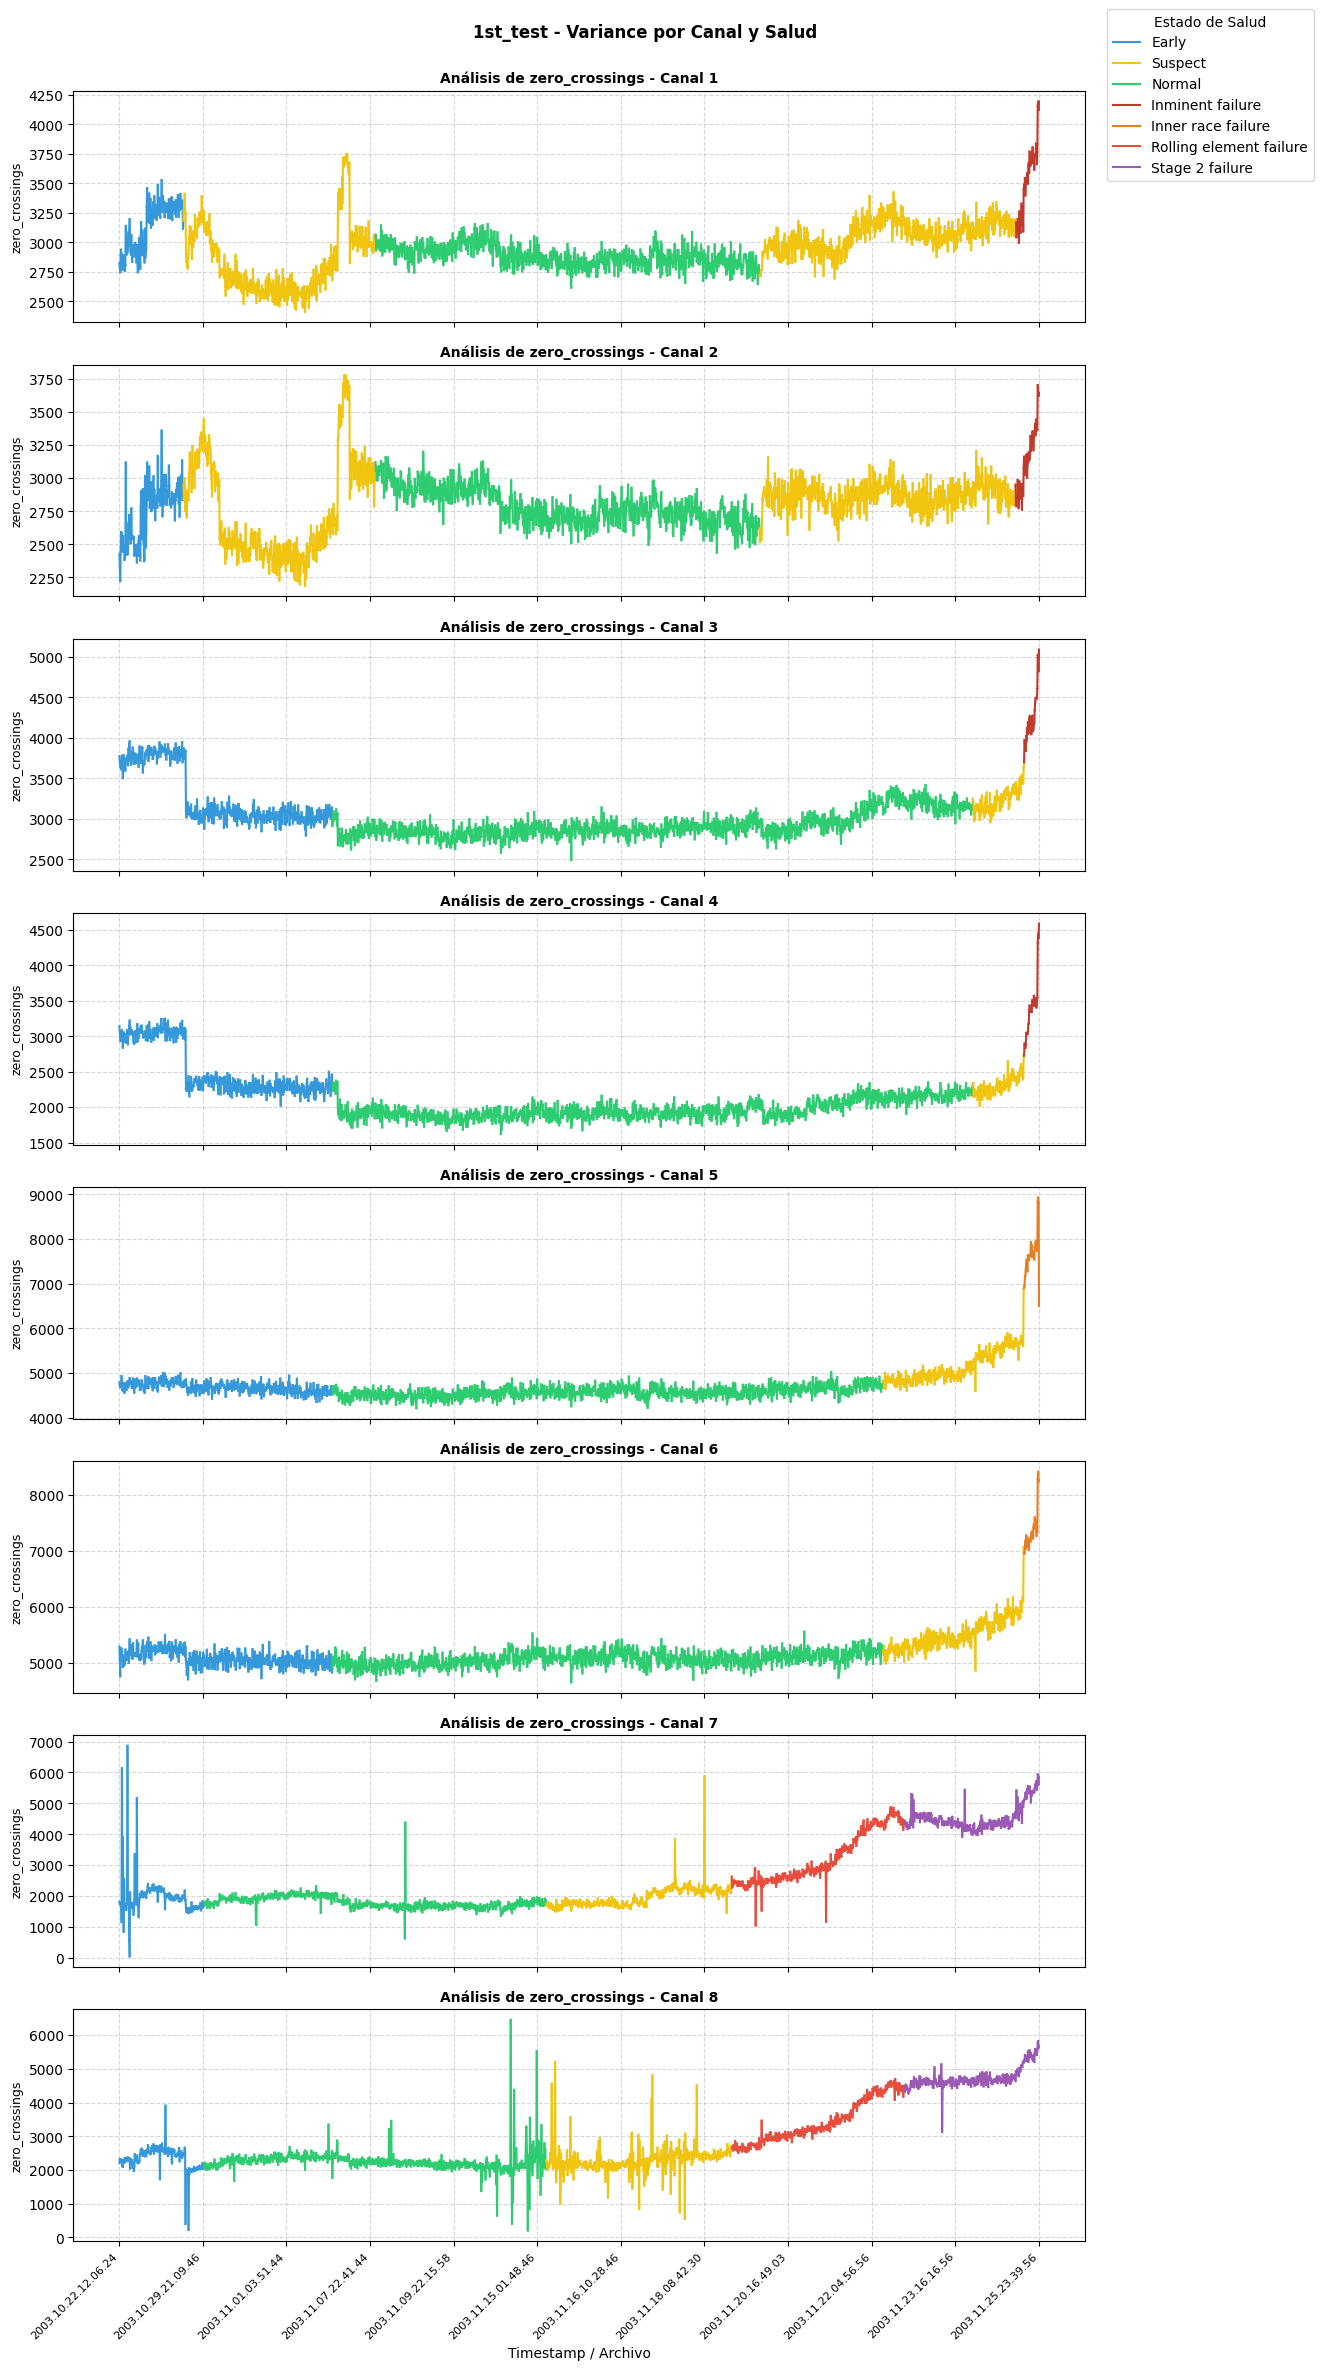

In [12]:
mostrar_grafica_agrupada(
    df,
    metrica='zero_crossings',
    columna_salud='salud_miltos',
    columna_canal='canal',
    colores_salud=COLORES_ETIQUETA,
    guardar_figura=True,
    titulo_grafica="1st_test - Variance por Canal y Salud",
    nombre_figura=os.path.join(dir_artifacts, "grafica_agrupada_1st_test_variance(train).png")
)

Figura guardada como: artefactos/artefactos_train_arq_v1/grafica_agrupada_2nd_test_variance(test).png


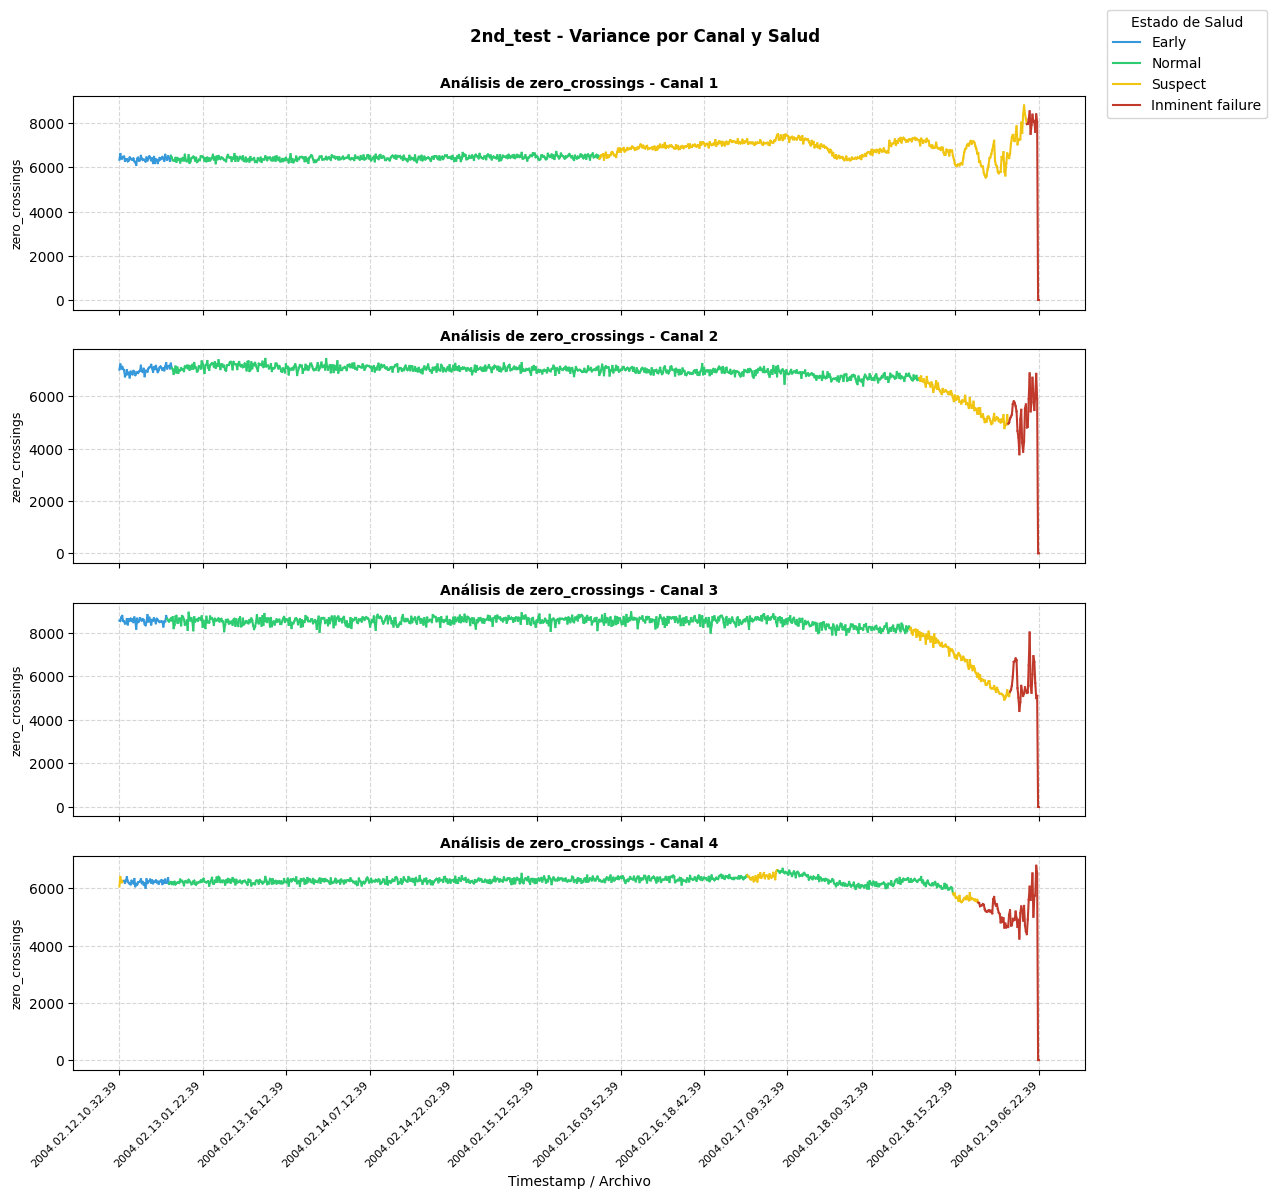

In [13]:
mostrar_grafica_agrupada(
    df_agregado_2nd_test,
    metrica='zero_crossings',
    columna_salud='vida_util',
    columna_canal='canal',
    colores_salud=COLORES_ETIQUETA,
    guardar_figura=True,
    titulo_grafica="2nd_test - Variance por Canal y Salud",
    nombre_figura=os.path.join(dir_artifacts, "grafica_agrupada_2nd_test_variance(test).png")
)

Figura guardada como: artefactos/artefactos_train_arq_v1/grafica_agrupada_3rd_test_variance(test).png


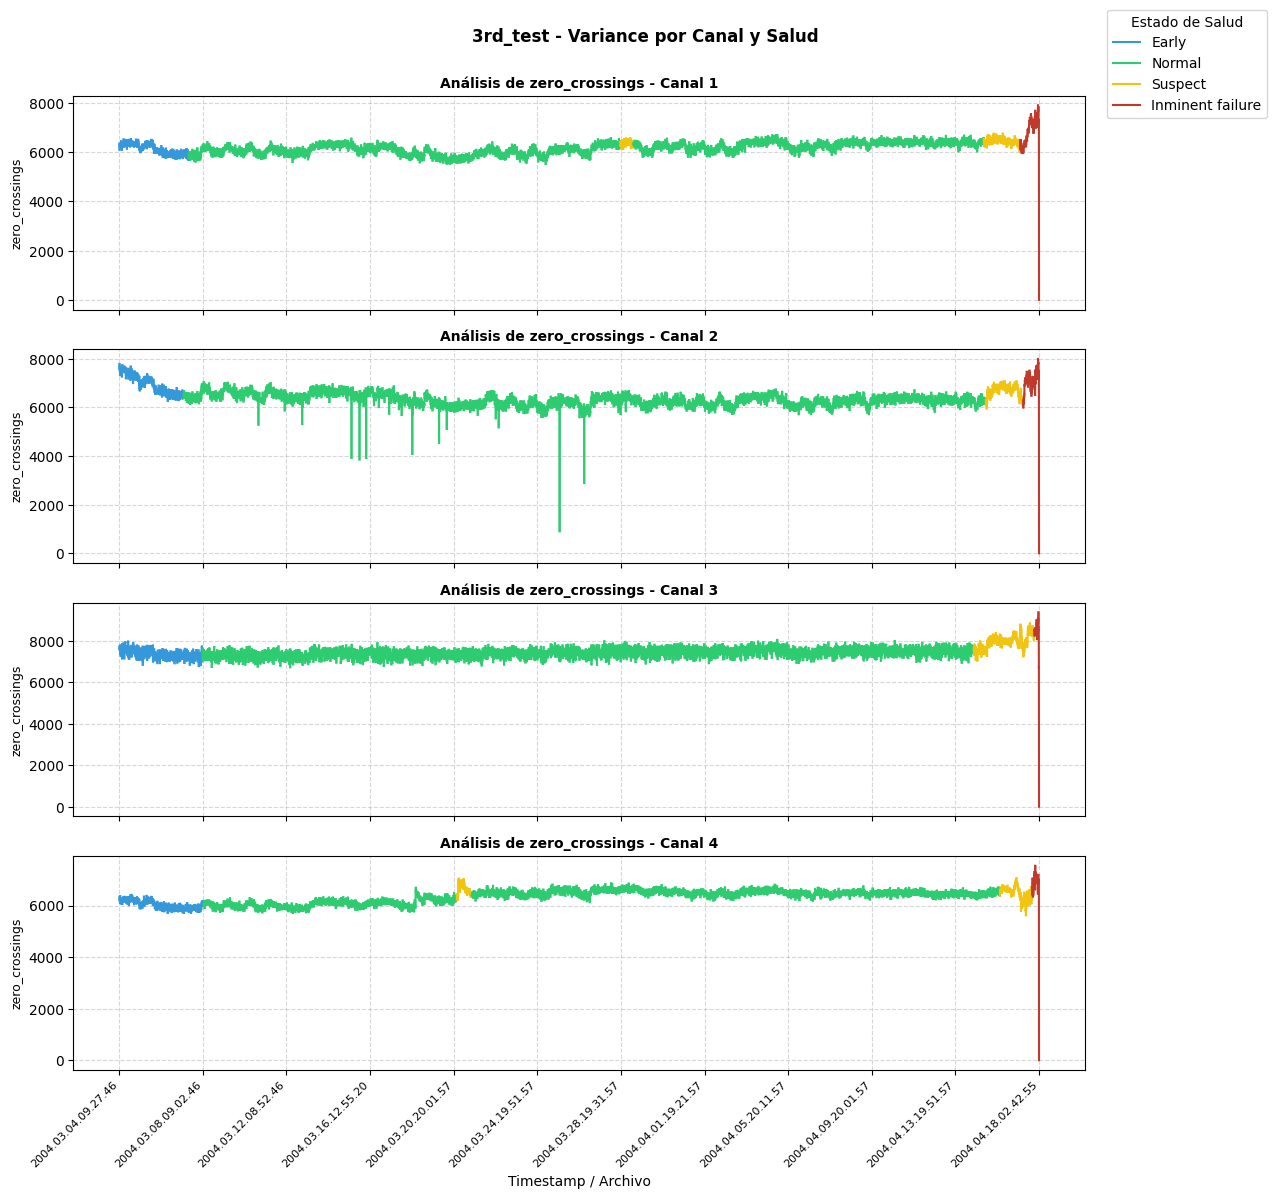

In [14]:
mostrar_grafica_agrupada(
    df_agregado_3rd_test,
    metrica='zero_crossings',
    columna_salud='vida_util',
    columna_canal='canal',
    colores_salud=COLORES_ETIQUETA,
    guardar_figura=True,
    titulo_grafica="3rd_test - Variance por Canal y Salud",
    nombre_figura=os.path.join(dir_artifacts, "grafica_agrupada_3rd_test_variance(test).png")
)

## Variables para control de filtrado de features

In [15]:
# VARIABLES PARA WANDB
media_shap = 0
TARGET = "salud_miltos"
DATASET_ANALISIS = "PEARSON"

ejecutar_analisis_shap = False
ejecutar_analisis_pearson = True
FEATURES_ESCOGIDOS = []
COLUMNAS_CATEGORICAS = ["archivo", "canal", "salud", "salud_miltos"]
COLUMNAS_CATEGORICAS_2nd_test = ["archivo", "canal", "vida_util"]
COLUMNAS_CATEGORICAS_3rd_test = ["archivo", "canal", "vida_util"]


## Análisis de correlación


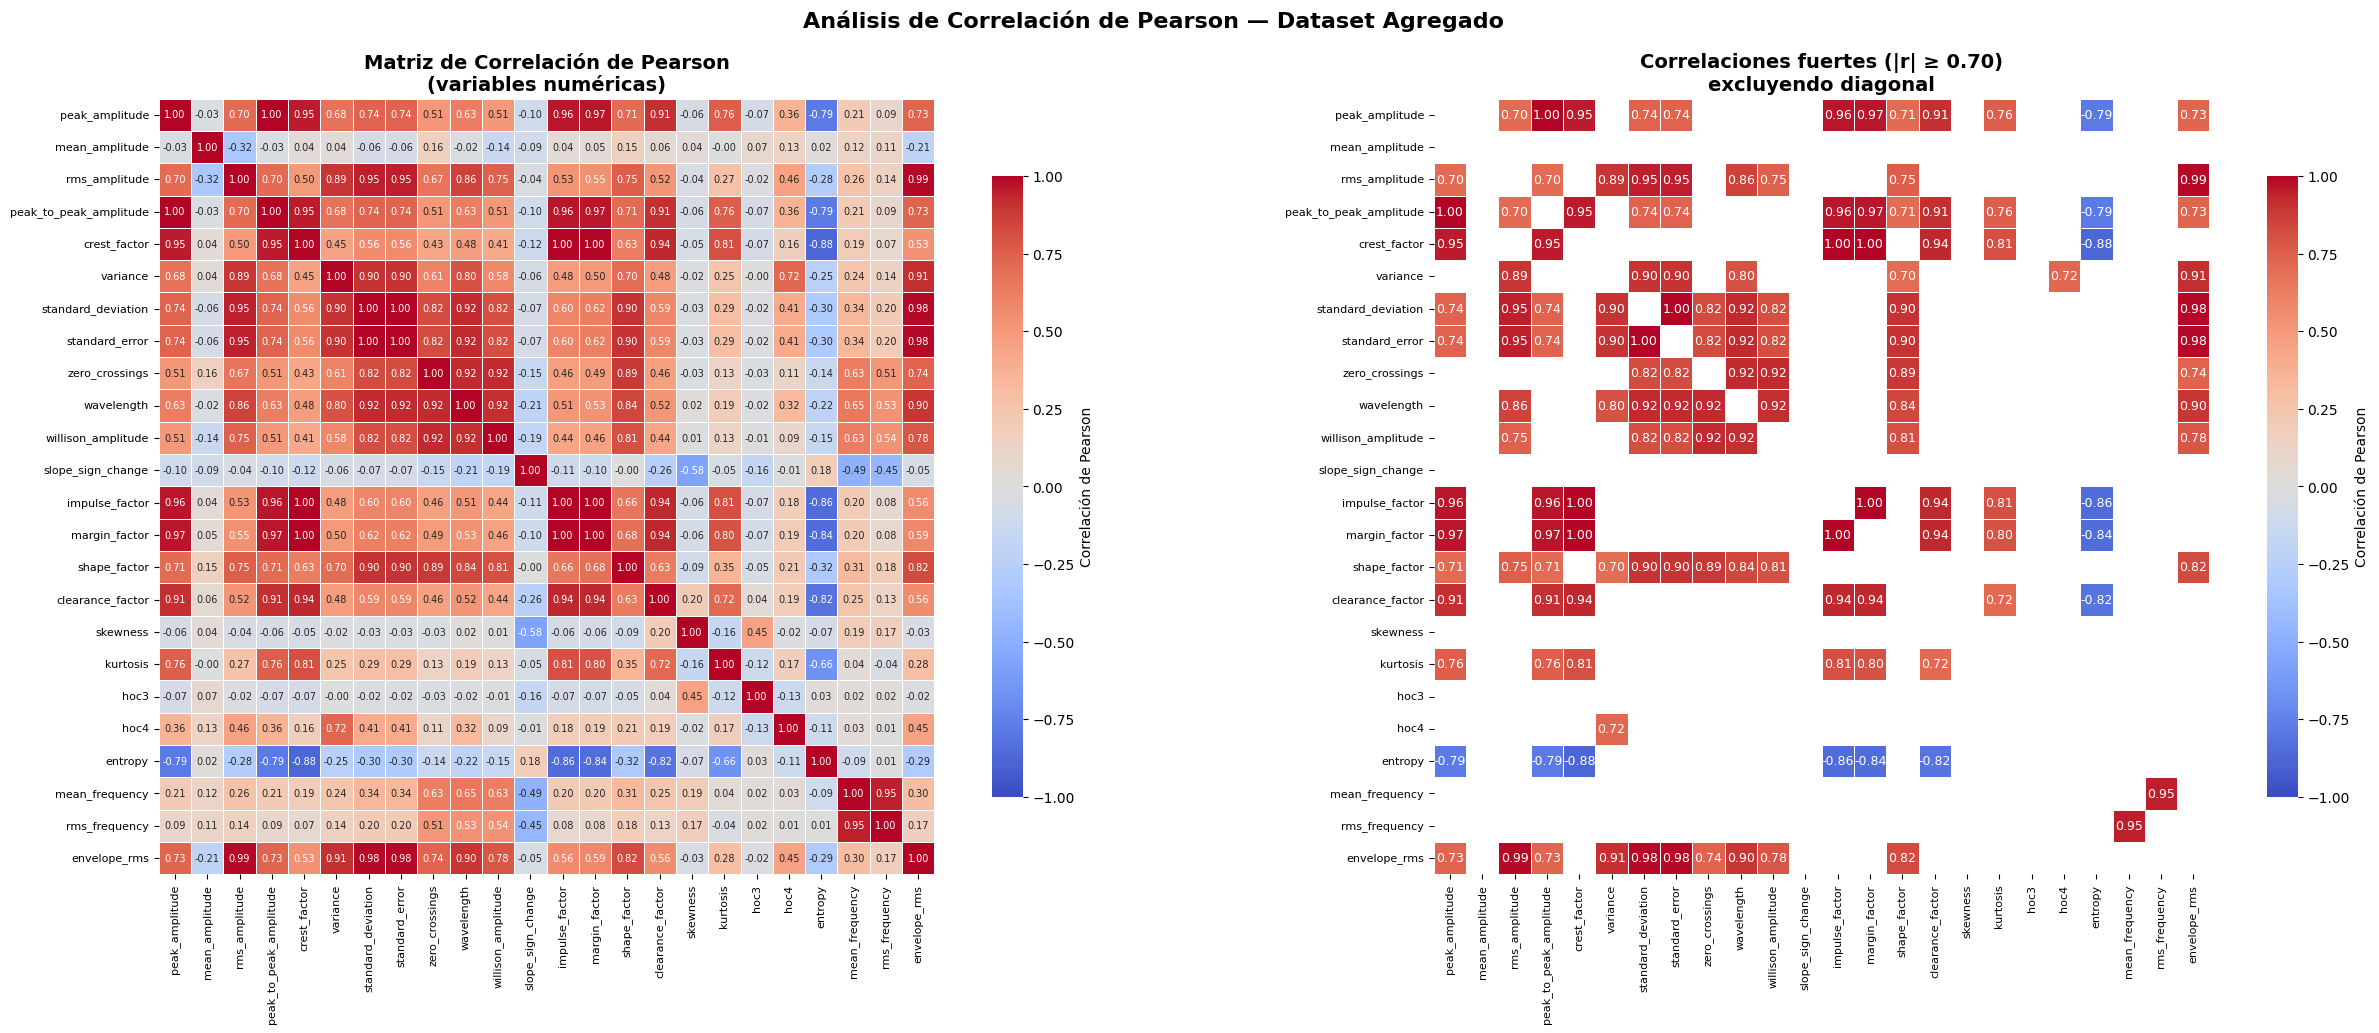

Umbral aplicado : |r| > 0.6
Variables conservadas: ['peak_amplitude', 'mean_amplitude', 'slope_sign_change', 'skewness', 'hoc3']


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if ejecutar_analisis_pearson:
    # ── Parámetros ───────────────────────────────────────────────────────────────
    DATASET_ANALISIS = "Pearson"
    UMBRAL_PEARSON = 0.6  # aquellas parámetros que sobrepasen el umbral de correlación serán eliminados


    # Seleccionar solo columnas numéricas
    df_num = df.select_dtypes(include=[np.number])

    # Calcular matriz de correlación de Pearson
    corr_matrix = df_num.corr(method='pearson')

    # ── Figura ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(26, 10))

    # 1) Heatmap completo
    sns.heatmap(
        corr_matrix,
        ax=axes[0],
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        annot_kws={"size": 7},
        square=True,
        cbar_kws={"shrink": 0.8, "label": "Correlación de Pearson"}
    )
    axes[0].set_title("Matriz de Correlación de Pearson\n(variables numéricas)", fontsize=14, fontweight="bold")
    axes[0].tick_params(axis='x', rotation=90, labelsize=8)
    axes[0].tick_params(axis='y', rotation=0,  labelsize=8)

    # 2) Heatmap de correlaciones fuertes (|r| >= 0.7), excluyendo la diagonal
    mask_weak = (corr_matrix.abs() < 0.7)
    np.fill_diagonal(mask_weak.values, True)   # ocultar diagonal

    sns.heatmap(
        corr_matrix,
        ax=axes[1],
        mask=mask_weak,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        annot_kws={"size": 9},
        square=True,
        cbar_kws={"shrink": 0.8, "label": "Correlación de Pearson"}
    )
    axes[1].set_title("Correlaciones fuertes (|r| ≥ 0.70)\nexcluyendo diagonal", fontsize=14, fontweight="bold")
    axes[1].tick_params(axis='x', rotation=90, labelsize=8)
    axes[1].tick_params(axis='y', rotation=0,  labelsize=8)

    plt.suptitle("Análisis de Correlación de Pearson — Dataset Agregado", fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(dir_artifacts + "/correlacion_pearson.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Identificar columnas a eliminar ─────────────────────────────────────────
    corr_matrix_abs = corr_matrix.abs()
    upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))
    # Por cada par correlacionado, se elimina la segunda columna (la de la derecha)
    cols_eliminar = set()
    for col in upper.columns:
        if any(upper[col] > UMBRAL_PEARSON):
            cols_eliminar.add(col)

    FEATURES_ESCOGIDOS = [c for c in df_num.columns if c not in cols_eliminar]

    print(f"Umbral aplicado : |r| > {UMBRAL_PEARSON}")
    print(f"Variables conservadas: {FEATURES_ESCOGIDOS}")


## Análisis de importancia SHAP

In [17]:

if ejecutar_analisis_shap:

    # ── Definir features y target ─────────────────────────────────────────────
    DATASET_ANALISIS = "SHAP"


    feature_cols = [c for c in df.columns if c not in COLUMNAS_CATEGORICAS]

    # Eliminar filas sin target o sin features
    df_model = df[feature_cols + [TARGET]].dropna(subset=[TARGET])
    df_model = df_model.dropna(subset=feature_cols)

    X = df_model[feature_cols]
    y_raw = df_model[TARGET]

    # Codificar target si es categórico
    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    clases = le.classes_
    print(f"Clases detectadas: {clases}")
    print(f"Shape X: {X.shape}  |  distribución y: {pd.Series(y).value_counts().to_dict()}")

    # ── 3. Train / Test split ────────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # ── 4. Entrenar modelo base (Random Forest) ──────────────────────────────────
    model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    print("\n── Reporte de clasificación ──")
    print(classification_report(y_test, model.predict(X_test), target_names=clases))


    # ── 5. Calcular valores SHAP ─────────────────────────────────────────────────
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    print(f"Tipo shap_values : {type(shap_values)}")
    if isinstance(shap_values, list):
        print(f"Nº clases        : {len(shap_values)}")
        print(f"Shape por clase  : {shap_values[0].shape}")
        is_multiclass = True
    else:
        print(f"Shape shap_values: {shap_values.shape}")
        is_multiclass = False

    # ── 6. DataFrame de importancia global ──────────────────────────────────────
    if is_multiclass:
        # Stack: (n_clases, n_muestras, n_features) → media absoluta sobre clases y muestras
        shap_stack     = np.stack(shap_values, axis=0)          # (n_clases, n_muestras, n_features)
        shap_abs_mean  = np.abs(shap_stack).mean(axis=(0, 1))   # (n_features,)  ← 1-D ✓
        shap_vals_plot = shap_values
    else:
        # Binario: shap_values puede ser (n_muestras, n_features) o (n_muestras, n_features, 2)
        if shap_values.ndim == 3:
            shap_abs_mean = np.abs(shap_values[:, :, 1]).mean(axis=0)   # clase positiva
        else:
            shap_abs_mean = np.abs(shap_values).mean(axis=0)            # (n_features,) ✓
        shap_vals_plot = shap_values

    print(f"shap_abs_mean shape: {shap_abs_mean.shape}")   # debe ser (n_features,)

    importancia = pd.DataFrame({
        "feature"       : feature_cols,
        "shap_mean_abs" : shap_abs_mean          # ya es 1-D, no necesita .mean()
    }).sort_values("shap_mean_abs", ascending=False).reset_index(drop=True)

    importancia["rank"] = importancia.index + 1
    print("\n── Importancia SHAP (global) ──")
    print(importancia.to_string(index=False))

    # ── 7. Visualizaciones ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))

    # 7-A  Bar plot de importancia global
    axes[0].barh(
        importancia["feature"][::-1],
        importancia["shap_mean_abs"][::-1],
        color=sns.color_palette("viridis", len(importancia))
    )
    axes[0].set_xlabel("mean(|SHAP value|)", fontsize=11)
    axes[0].set_title("Importancia Global SHAP\n(todas las clases)", fontsize=13, fontweight="bold")
    axes[0].axvline(importancia["shap_mean_abs"].mean(), color="red", linestyle="--", label="Media global")
    axes[0].legend(fontsize=9)

    # 7-B  Beeswarm / Summary plot (usa la API de shap directamente)
    plt.sca(axes[1])
    if is_multiclass:
        # Para multiclase tomamos la clase de mayor índice (la "positiva" o última)
        shap.summary_plot(
            shap_vals_plot[-1], X_test,
            feature_names=feature_cols,
            show=False, plot_size=None, color_bar=True
        )
    else:
        shap.summary_plot(
            shap_vals_plot, X_test,
            feature_names=feature_cols,
            show=False, plot_size=None, color_bar=True
        )
    axes[1].set_title(f"Beeswarm SHAP\n(clase: {clases[-1]})", fontsize=13, fontweight="bold")

    # 7-C  Heatmap: SHAP medio por clase
    if is_multiclass:
        shap_por_clase = pd.DataFrame(
            {cls: np.abs(sv).mean(axis=0) for cls, sv in zip(clases, shap_vals_plot)},
            index=feature_cols
        ).sort_values(by=clases[0], ascending=False)

        sns.heatmap(
            shap_por_clase,
            ax=axes[2],
            cmap="YlOrRd",
            annot=True, fmt=".3f",
            linewidths=0.4,
            cbar_kws={"label": "mean(|SHAP|)"}
        )
        axes[2].set_title("mean(|SHAP|) por clase", fontsize=13, fontweight="bold")
        axes[2].tick_params(axis='x', rotation=30, labelsize=9)
        axes[2].tick_params(axis='y', rotation=0,  labelsize=9)
    else:
        axes[2].axis("off")

    plt.suptitle("Análisis de Importancia de Parámetros — SHAP", fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("shap_importancia.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── 8. Guardar tabla de importancia ─────────────────────────────────────────
    # importancia.to_csv("shap_importancia.csv", index=False)

In [18]:
if ejecutar_analisis_shap:
    # armado de dataset con las clases originales por encima de la media 
    # ── Filtrar features por encima de la media SHAP ────────────────────────────
    # media_shap = importancia["shap_mean_abs"].mean()
    # print(f"Media SHAP global: {media_shap:.4f}")

    # umbral_shap = media_shap  # puedes ajustar este valor según tus necesidades
    umbral_shap = 0.006 # umbral fijo (opcional)

    importancia_filtrada = importancia[importancia["shap_mean_abs"] > umbral_shap].reset_index(drop=True)
    importancia_filtrada["rank"] = importancia_filtrada.index + 1

    print(f"\nFeatures totales         : {len(importancia)}")
    print(f"Features sobre la media  : {len(importancia_filtrada)}")
    print(f"Features descartadas     : {len(importancia) - len(importancia_filtrada)}")
    print("\n── Features seleccionadas ──")
    print(importancia_filtrada.to_string(index=False))

    # ── Construir subconjunto del dataset ────────────────────────────────────────
    cols_seleccionadas = importancia_filtrada["feature"].tolist()
    # OPCIONAL establecerlas manualmente 
    # cols_seleccionadas = ['rms_frequency', 'mean_frequency', 'standard_deviation', 'standard_error', 'variance', 'hoc4', 'envelope_rms', 'mean_amplitude', 'kurtosis', 'rms_amplitude', 'wavelength']

    FEATURES_ESCOGIDOS = cols_seleccionadas.copy()  # actualizar variable global para usarla luego en el entrenamiento

    print(f"\nColumnas seleccionadas: {cols_seleccionadas}")

    # ── Visualización ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 6))

    colores = ["steelblue" if v > umbral_shap else "lightgray"
            for v in importancia["shap_mean_abs"]]

    ax.barh(importancia["feature"][::-1], importancia["shap_mean_abs"][::-1], color=colores[::-1])
    ax.axvline(umbral_shap, color="red", linestyle="--", linewidth=1.5, label=f"Umbral = {umbral_shap:.4f}")
    ax.set_xlabel("mean(|SHAP value|)", fontsize=11)
    ax.set_title("Features seleccionadas por encima de la media SHAP\n(azul = seleccionadas, gris = descartadas)",
                fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(dir_artifacts + "/shap_seleccion_media.png", dpi=150, bbox_inches="tight")
    plt.show()

## Filtrado de features

In [19]:

if ejecutar_analisis_pearson or ejecutar_analisis_shap:
    # (OPCIONAL) establecer manualmente las features a conservar
    # FEATURES_ESCOGIDOS = ["rms_frequency", "mean_frequency", "standard_deviation", "standard_error", "variance", "hoc4", "envelope_rms", "mean_amplitude", "kurtosis", "rms_amplitude", "wavelength"]

    # ── Reporte ──────────────────────────────────────────────────────────────────
    print(f"Variables conservadas: {len(FEATURES_ESCOGIDOS)}")

    # ── Dataset final (numéricas filtradas + categóricas originales) ─────────────
    df_filtrado = df[COLUMNAS_CATEGORICAS + FEATURES_ESCOGIDOS]  # mantener solo las columnas seleccionadas
    df_mk_cnn_base_filtrado = df[COLUMNAS_CATEGORICAS + ["peak_amplitude", "mean_amplitude","slope_sign_change","skewness","hoc3"]]  # mantener solo las columnas seleccionadas
    df_lstm_base_filtrado = df[COLUMNAS_CATEGORICAS + FEATURES_ESCOGIDOS]  # mantener solo las columnas seleccionadas

    df_agregado_2nd_test_filtrado = df_agregado_2nd_test[COLUMNAS_CATEGORICAS_2nd_test + FEATURES_ESCOGIDOS]
    df_agregado_3rd_test_filtrado = df_agregado_3rd_test[COLUMNAS_CATEGORICAS_3rd_test + FEATURES_ESCOGIDOS]


    print(f"\nShape original : {df.shape}")
    print(f"Shape filtrado : {df_filtrado.shape}")

    df = df_filtrado.copy()  # actualizar df para usar el dataset filtrado en adelante

    df_agregado_2nd_test = df_agregado_2nd_test_filtrado.copy()
    df_agregado_3rd_test = df_agregado_3rd_test_filtrado.copy()
    # Guardar (opcional)
    df_filtrado.to_csv(f"{dir_artifacts}/dataset.csv", index=False)

Variables conservadas: 5

Shape original : (17248, 28)
Shape filtrado : (17248, 9)


## Armado de tensores


### Tensores 1st_test

In [20]:
import numpy as np
from scipy.stats import kurtosis

# crear copia para trabajar
df_copy = df.copy()

# codificar canal como número entero
df_copy["canal"] = df_copy["canal"].str.extract(r'(\d+)').astype(int)

# separacion de features y target
features = df_copy.columns.drop(["archivo", "canal", "salud_miltos", "salud"])


experimentos = df_copy["archivo"].unique()

X = []
y = []

for exp in experimentos:
    
    bloque = df_copy[df_copy["archivo"] == exp].sort_values("canal")

    # matriz 8 x features
    matriz = bloque[features].values

    X.append(matriz)
    
    # target del experimento
    y.append(bloque["salud_miltos"].iloc[0])

X = np.array(X)
y = np.array(y)

print(f"forma de X: {X.shape}")
print(f"forma de y: {y.shape}")

forma de X: (2156, 8, 5)
forma de y: (2156,)


In [21]:
# Codificación de clases 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)
num_classes = len(le.classes_)

for cls, idx in zip(le.classes_, range(num_classes)):
    print(f"Clase '{cls}' → {idx}")

Clase 'Early' → 0
Clase 'Inminent failure' → 1
Clase 'Normal' → 2
Clase 'Suspect' → 3


In [22]:
# Separación (train + validation + test)

from sklearn.model_selection import train_test_split

# 1. Separación sobre el 100% de los datos en Train (80%) y Test (20%) 
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Separación sobre el 80% de los datos en Train (70%) y Valid (10%)
# test_size=0.125 porque 0.125 * 0.8 = 0.1 (10% del total) 
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_temp, y_train_temp, test_size=0.125, random_state=42, stratify=y_train_temp
)

In [23]:
X_train.shape

(1508, 8, 5)

In [24]:
# Estandarización de features 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_train = X_train_scaled.reshape(X_train.shape)


# Para Test
X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])
X_test_scaled = scaler.transform(X_test_reshaped) 
X_test = X_test_scaled.reshape(X_test.shape)

# Para Valid
X_valid_reshaped = X_valid.reshape(-1, X_valid.shape[-1])
X_valid_scaled = scaler.transform(X_valid_reshaped) 
X_valid = X_valid_scaled.reshape(X_valid.shape)

In [25]:
# ====== DATA AUGMENTATION (Opcional) ======

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# ---------- FUNCIONES DE AUGMENTATION ----------
def add_noise(X, noise_level=0.01):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

def scaling(X, sigma=0.1):
    factor = np.random.normal(1.0, sigma, (X.shape[0], 1, 1))
    return X * factor

def time_shift(X, shift_max=5):
    X_shifted = np.zeros_like(X)
    for i in range(X.shape[0]):
        shift = np.random.randint(-shift_max, shift_max)
        X_shifted[i] = np.roll(X[i], shift, axis=0)
    return X_shifted

# ---------- IDENTIFICAR CLASE MINORITARIA ----------
classes, counts = np.unique(y_train, return_counts=True)
minority_class = classes[np.argmin(counts)]

# ---------- EXTRAER CLASE MINORITARIA ----------
X_min = X_train[y_train == minority_class]

# ---------- GENERAR DATOS AUMENTADOS ----------
X_aug = add_noise(X_min)
X_aug = np.concatenate([
    X_aug,
    scaling(X_min),
    time_shift(X_min)
])

y_aug = np.full(len(X_aug), minority_class)

# ---------- COMBINAR DATASET ----------
X_train = np.concatenate([X_train, X_aug])
y_train = np.concatenate([y_train, y_aug])

# ---------- CALCULAR CLASS WEIGHT ----------
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight = dict(zip(np.unique(y_train), weights))

# ---------- INFO DEBUG ----------
print("Shape original:", X_train.shape)
print("Shape final:", X_train.shape)
print("Distribución original:", dict(zip(classes, counts)))
print("Distribución nueva:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Class weights:", class_weight)


Shape original: (1625, 8, 5)
Shape final: (1625, 8, 5)
Distribución original: {0: 105, 1: 39, 2: 630, 3: 734}
Distribución nueva: {0: 105, 1: 156, 2: 630, 3: 734}
Class weights: {0: 3.869047619047619, 1: 2.6041666666666665, 2: 0.6448412698412699, 3: 0.5534741144414169}


In [26]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1625, 8, 5), (1625,), (432, 8, 5), (432,))

In [27]:
# remapeo para usar solo clases vistas en el train
print("Etiquetas únicas finales en 2nd_test:", df_agregado_2nd_test['vida_util'].unique())
print("Etiquetas únicas finales en 3rd_test:", df_agregado_3rd_test['vida_util'].unique())

Etiquetas únicas finales en 2nd_test: ['Early' 'Suspect' 'Normal' 'Inminent failure']
Etiquetas únicas finales en 3rd_test: ['Early' 'Normal' 'Suspect' 'Inminent failure']


In [28]:
# 1. Definimos el diccionario de homologación
# Vincula cualquier variante o falla específica a tus 4 clases oficiales
mapeo_clases_disponibles_entrenamiento = {
    "Inner race failure": "Inminent failure", 
    "Stage 2 failure": "Inminent failure",
    "Early": "Early",
    "Normal": "Normal",
    "Inminent failure": "Inminent failure",
    "Suspect": "Suspect"
}

# 2. Aplicamos la reasignación en el 2nd_test
# Usamos .map() y si encuentra algo que no está en el diccionario, lo deja como NaN
df_agregado_2nd_test['vida_util'] = df_agregado_2nd_test['vida_util'].map(mapeo_clases_disponibles_entrenamiento)

# 3. Aplicamos la reasignación en el 3rd_test
df_agregado_3rd_test['vida_util'] = df_agregado_3rd_test['vida_util'].map(mapeo_clases_disponibles_entrenamiento)

# --- CONTROL DE CALIDAD ---
# Verificamos si quedó alguna etiqueta sin mapear (que daría error de nuevo)
print("Etiquetas únicas finales en 2nd_test:", df_agregado_2nd_test['vida_util'].unique())
print("Etiquetas únicas finales en 3rd_test:", df_agregado_3rd_test['vida_util'].unique())

Etiquetas únicas finales en 2nd_test: ['Early' 'Suspect' 'Normal' 'Inminent failure']
Etiquetas únicas finales en 3rd_test: ['Early' 'Normal' 'Suspect' 'Inminent failure']


### Tensores de 2nd_test

In [29]:
import numpy as np


# codificar canal como número entero, para mantenerlo como feature en el modelo
df_agregado_2nd_test_copy = df_agregado_2nd_test.copy()

# duplicar canales para tener 8 filas por experimento (si no las tiene ya)
nuevos_canales_list = []
for i in range(0, len(df_agregado_2nd_test_copy), 4):
    bloque_original = df_agregado_2nd_test_copy.iloc[i : i + 4].copy()
    nuevo_bloque = bloque_original.copy()
    mapeo_canales = {
        "Canal 1": "Canal 5",
        "Canal 2": "Canal 6",
        "Canal 3": "Canal 7",
        "Canal 4": "Canal 8"
    }
    nuevo_bloque["canal"] = nuevo_bloque["canal"].map(mapeo_canales)
    nuevos_canales_list.append(nuevo_bloque)
    
df_nuevos_canales = pd.concat(nuevos_canales_list, ignore_index=True)
df_agregado_2nd_test_copy = pd.concat([df_agregado_2nd_test_copy, df_nuevos_canales], ignore_index=True)
df_agregado_2nd_test_copy = df_agregado_2nd_test_copy.sort_values(by=["archivo", "canal"]).reset_index(drop=True)

df_agregado_2nd_test_copy["canal"] = df_agregado_2nd_test_copy["canal"].str.extract(r'(\d+)').astype(int)

# separacion de features y target
features = df_agregado_2nd_test_copy.columns.drop(["archivo", "canal", "vida_util"])

# features escogidos manualmente 
experimentos = df_agregado_2nd_test_copy.loc[:, FEATURES_ESCOGIDOS]
experimentos = df_agregado_2nd_test_copy["archivo"].unique()

X_2nd_test = []
y_2nd_test = []

for exp in experimentos:
    
    bloque = df_agregado_2nd_test_copy[df_agregado_2nd_test_copy["archivo"] == exp].sort_values("canal")
    
    # matriz 8 x features
    matriz = bloque[features].values
    
    X_2nd_test.append(matriz)
    
    # target del experimento
    y_2nd_test.append(bloque["vida_util"].iloc[0])

X_2nd_test = np.array(X_2nd_test)
y_2nd_test = np.array(y_2nd_test)

print(X_2nd_test.shape)
print(y_2nd_test.shape)

(984, 8, 5)
(984,)


In [30]:
# codificacion de clases 

# le = LabelEncoder()
y_2nd_test = le.transform(y_2nd_test)


In [31]:
# estandarización de features (usar el mismo scaler que para el entrenamiento)
scaler = StandardScaler()

# Sólo Test
X_2nd_test_reshaped = X_2nd_test.reshape(-1, X_2nd_test.shape[-1])
X_2nd_test_scaled = scaler.fit_transform(X_2nd_test_reshaped)
X_2nd_test = X_2nd_test_scaled.reshape(X_2nd_test.shape)


In [32]:
# X_train.shape, y_train.shape, X_test.shape, y_test.shape
X_2nd_test.shape, y_2nd_test.shape

((984, 8, 5), (984,))

### Tensores de 3er_test

In [33]:
from scipy.stats import kurtosis

# codificar canal como número entero, para mantenerlo como feature en el modelo
df_agregado_3rd_test_copy = df_agregado_3rd_test.copy()

# duplicar canales para tener 8 filas por experimento (si no las tiene ya)
nuevos_canales_list = []
for i in range(0, len(df_agregado_3rd_test_copy), 4):
    bloque_original = df_agregado_3rd_test_copy.iloc[i : i + 4].copy()
    nuevo_bloque = bloque_original.copy()
    mapeo_canales = {
        "Canal 1": "Canal 5",
        "Canal 2": "Canal 6",
        "Canal 3": "Canal 7",
        "Canal 4": "Canal 8"
    }
    nuevo_bloque["canal"] = nuevo_bloque["canal"].map(mapeo_canales)
    nuevos_canales_list.append(nuevo_bloque)

df_nuevos_canales = pd.concat(nuevos_canales_list, ignore_index=True)
df_agregado_3rd_test_copy = pd.concat([df_agregado_3rd_test_copy, df_nuevos_canales], ignore_index=True)
df_agregado_3rd_test_copy = df_agregado_3rd_test_copy.sort_values(by=["archivo", "canal"]).reset_index(drop=True)

df_agregado_3rd_test_copy["canal"] = df_agregado_3rd_test_copy["canal"].str.extract(r'(\d+)').astype(int)

# separacion de features y target
features = df_agregado_3rd_test_copy.columns.drop(["archivo", "canal", "vida_util"])

# features escogidos manualmente 
experimentos = df_agregado_3rd_test_copy.loc[:, FEATURES_ESCOGIDOS]
experimentos = df_agregado_3rd_test_copy["archivo"].unique()

X_3rd_test = []
y_3rd_test = []

for exp in experimentos:
    
    bloque = df_agregado_3rd_test_copy[df_agregado_3rd_test_copy["archivo"] == exp].sort_values("canal")
    
    # matriz 8 x features
    matriz = bloque[features].values
    
    X_3rd_test.append(matriz)
    
    # target del experimento
    y_3rd_test.append(bloque["vida_util"].iloc[0])

X_3rd_test = np.array(X_3rd_test)
y_3rd_test = np.array(y_3rd_test)

print(X_3rd_test.shape)
print(y_3rd_test.shape)

(6324, 8, 5)
(6324,)


In [34]:
# codificacion de clases 
from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
y_3rd_test = le.transform(y_3rd_test)


In [35]:
# Normalización de features (usar el mismo scaler que para el entrenamiento)
scaler = StandardScaler()

# Sólo Test
X_3rd_test_reshaped = X_3rd_test.reshape(-1, X_3rd_test.shape[-1])
X_3rd_test_scaled = scaler.fit_transform(X_3rd_test_reshaped) 
X_3rd_test = X_3rd_test_scaled.reshape(X_3rd_test.shape)


In [36]:
# X_train.shape, y_train.shape, X_3rd_test.shape, y_3rd_test.shape
X_3rd_test.shape, y_3rd_test.shape

((6324, 8, 5), (6324,))

# Config Wandb (dataset)

In [38]:
# variable para controlar si usar o no wandb
usar_wandb = True


# guardar datos del dataset
if usar_wandb:
    #diccionario con los parámetros del dataset
    config_params_dataset = {
        "dataset/num_samples" : len(df),
        "dataset/num_features": len(features),
        "dataset/num_classes" : len(le.classes_),
        "dataset/original_shape" : df.shape,
        "dataset/train_set_shape" : X.shape,
        "dataset/test_set_shape_1" : X_2nd_test.shape,
        "dataset/test_set_shape_2" : X_3rd_test.shape,
        "dataset/features"    : features.tolist(),
        "dataset/target"      : TARGET,
        "dataset/analysis"    : DATASET_ANALISIS,
        "dataset/shap_mean_threshold": umbral_shap,
        "data_test1/name": df_agregado_2nd_test_name,
        "data_test2/name": df_agregado_3rd_test_name,
    }
    # Crear un artefacto para datos del dataset
    dataset_artifact = wandb.Artifact(
        name="IMS_agregado_filtrado_v1", 
        type="dataset",
        description="Dataset tras eliminar variables con valor de importancia SHAP por debajo de la media global."
    )

    # Crear un artefacto las graficas generadas en el análisis
    figures_artifact = wandb.Artifact(
        name="IMS_graficas_analisis_v1", 
        type="figures",
        description="Graficas generadas en el análisis de los datos."
    )

    # 2. Función auxiliar para evitar errores de rutas y archivos inexistentes
    def agregar_si_existe(ruta_carpeta, nombre_archivo, artefacto):
        ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)
        if os.path.exists(ruta_completa):
            # name= especifica cómo se llamará el archivo DENTRO de wandb
            artefacto.add_file(ruta_completa, name=nombre_archivo)
        else:
            print(f"⚠️ Advertencia: No se encontró el archivo en {ruta_completa}")

    # guaradado del dataset de entrenamiento y test
    agregar_si_existe(dir_artifacts, "dataset.csv", dataset_artifact)

    # guardar imagenes de las graficas de SHAP y Pearson si aplica 
    if ejecutar_analisis_pearson:
        agregar_si_existe(dir_artifacts, "correlacion_pearson.png", figures_artifact)
    if ejecutar_analisis_shap:
        agregar_si_existe(dir_artifacts, "shap_importance.png", figures_artifact)

    # guardar graficas agrupadas del estadisticos seleccionados por canal y salud
    agregar_si_existe(dir_artifacts, "grafica_agrupada_1st_test_variance(train).png", figures_artifact)
    agregar_si_existe(dir_artifacts, "grafica_agrupada_2nd_test_variance(test).png", figures_artifact)
    agregar_si_existe(dir_artifacts, "grafica_agrupada_3rd_test_variance(test).png", figures_artifact)


In [ ]:
import os
import wandb

# variable para controlar si usar o no wandb
usar_wandb = True

# guardar datos del dataset
if usar_wandb:

    # Crear un artefacto para el dataset
    dataset_artifact = wandb.Artifact(
        name="IMS_agregado_filtrado_v1", 
        type="dataset",
        description="Dataset"
    )

    # Crear un artefacto las graficas generadas en el análisis
    figures_artifact = wandb.Artifact(
        name="IMS_graficas_analisis_v1", 
        type="figures",
        description="Graficas generadas en el análisis de los datos."
    )

    # 2. Función auxiliar para evitar errores de rutas y archivos inexistentes
    def agregar_si_existe(ruta_carpeta, nombre_archivo, artefacto):
        ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)
        if os.path.exists(ruta_completa):
            # name= especifica cómo se llamará el archivo DENTRO de wandb
            artefacto.add_file(ruta_completa, name=nombre_archivo)
        else:
            print(f"⚠️ Advertencia: No se encontró el archivo en {ruta_completa}")

    # guaradado del dataset
    agregar_si_existe(dir_artifacts, "dataset.csv", dataset_artifact)

    # guardar imagenes de las graficas de SHAP y Pearson si aplica 
    if ejecutar_analisis_pearson:
        agregar_si_existe(dir_artifacts, "correlacion_pearson.png", figures_artifact)
    if ejecutar_analisis_shap:
        agregar_si_existe(dir_artifacts, "shap_importance.png", figures_artifact)

    # guardar graficas agrupadas del estadisticos seleccionados por canal y salud
    agregar_si_existe(dir_artifacts, "grafica_agrupada_1st_test_variance(train).png", figures_artifact)
    agregar_si_existe(dir_artifacts, "grafica_agrupada_2nd_test_variance(test).png", figures_artifact)
    agregar_si_existe(dir_artifacts, "grafica_agrupada_3rd_test_variance(test).png", figures_artifact)


# MK_CNN - Base
arquitectura base obtenida de la comparacion de otras arquitecturas en el notebook `TF_entrenamiento_agregados_v7.ipynb`

In [136]:
# elegir si usar dataset_base o dataset definido en esta ejecución
usar_dataset_base = True
if usar_dataset_base:
    print(f"Usando dataset base")
    # guardando referencias para volver a usarlas luego en otro modelo
    X_train_temp, y_train_temp, X_valid_temp, y_valid_temp, X_test_temp, y_test_temp = X_train, y_train, X_valid, y_valid, X_test, y_test


    # validar que exita el dataset IMS_dataset_cnn_base.csv en el sistema de archivos
    nombre_dataset_base = "IMS_dataset_cnn_base.csv"
    nombre_generico_original = "dataset.csv"
    ruta_dataset_cnn_base = os.path.join(dir_artifacts, nombre_dataset_base)

    if not os.path.exists(ruta_dataset_cnn_base):   
        print(f"⚠️ Dataset '{nombre_dataset_base}' no encontrado en la ruta '{dir_artifacts}'. Intentando descargar desde wandb...")

        # 1. Inicializar un run de lectura/descarga (o usar un objeto API)
        run = wandb.init(project="vibraciones_conv1d", job_type="download_dataset")

        # 2. Ruta del artefacto
        artifact_path = "maanmuri-marck/TF_CEIA_Clasificador_Vibraciones_comparacion2/IMS_agregado_filtrado_v1:v1"
        artifact = run.use_artifact(artifact_path)

        # 3. Descargar el artefacto a una carpeta local (por defecto crea una carpeta './artifacts/', pero se guardara en la carpeta de artifacts del proyecto)
        artifact.download(root=dir_artifacts)

        # 4. renombrar 
        print(f"Renombrando archivo descargado '{nombre_generico_original}' a '{nombre_dataset_base}'...")
        os.rename(f"{dir_artifacts}/{nombre_generico_original}", f"{dir_artifacts}/{nombre_dataset_base}")

        run.finish()

    # Cargar el dataset base (en este caso el dataset se realizado una analisis de importancia 
    # Pearson y descarto la mayoría de las features, dejando solo las más importantes)
    df_base = pd.read_csv(f"{dir_artifacts}/{nombre_dataset_base}")
    print(" Dataset base cargado con éxito")

    # Limpieza, codificacion y balanceo de clases
    X_train, y_train, X_valid, y_valid, X_test, y_test = obtener_tensores_de_DF(df_base, separar_train_test=True, data_aumentation=True)





Usando dataset base
 Dataset base cargado con éxito


In [137]:
def create_base_model(X, num_classes):
    model = Sequential([
        Conv1D(
            filters=128,
            kernel_size=3,
            activation="relu",
            padding='same',
            input_shape=(X.shape[1], X.shape[2])
        ),
        MaxPooling1D(pool_size=2),
        Conv1D(
            filters=64,
            kernel_size=2,
            activation="relu",
            padding='same'
        ),
        Flatten(),
        Dense(
            units=32,
            activation="relu"
        ),
        Dropout(
            rate=0.4
        ),
        Dense(num_classes, activation="softmax")
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0015980108835268547
        ),
        loss='sparse_categorical_crossentropy',
        metrics=[
            "accuracy", 
            SparseRecallMacro(num_classes=num_classes), 
            F1MacroScore(num_classes=num_classes)
            ]
    )
    return model

# Instanciar el modelo de manera directa
num_classes = len(np.unique(y_train))
base_model = create_base_model(X_train, num_classes)

# Mostrar la estructura del modelo en consola
base_model.summary()


Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_8 (Conv1D)           (None, 8, 128)            2048      
                                                                 
 max_pooling1d_4 (MaxPoolin  (None, 4, 128)            0         
 g1D)                                                            
                                                                 
 conv1d_9 (Conv1D)           (None, 4, 64)             16448     
                                                                 
 flatten_4 (Flatten)         (None, 256)               0         
                                                                 
 dense_8 (Dense)             (None, 32)                8224      
                                                                 
 dropout_4 (Dropout)         (None, 32)                0         
                                                      

In [138]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones_comparacion2",
        name=f"CNN_BASE_Agregados_v6_{timestap_str}",
        tags=["cnn_base",],
        # config={**config_params, **config_params_dataset}

    )
    wandb.config.update({
        "filters_1": 128,
        "kernel_size_1": 3,
        "filters_2": 64,
        "kernel_size_2": 2,
        "dense_units": 32,
        "dropout_rate": 0.4,
        "learning_rate": 0.0015980108835268547,
        "stop_early_monitor": "val_loss"
    })
    wandb.log_artifact(dataset_artifact)
    wandb.log_artifact(figures_artifact)

In [139]:
# Configurar el callback de Early Stopping
# Monitoreamos 'val_loss' directamente desde el entrenamiento estándar
stop_early = tf.keras.callbacks.EarlyStopping(
    # monitor='recall_macro', 
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True # Recomendado: recupera los mejores pesos al terminar
)

# Entrenar el modelo directamente con .fit()
history = base_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_data=(X_valid, y_valid),
    callbacks=[stop_early]
)

Epoch 1/40
199/204 [============================>.] - ETA: 0s - loss: 0.6696 - accuracy: 0.7356 - recall_macro: 0.7356 - f1_score: 0.7389

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:2723: UserWarning: Metric SparseRecallMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


204/204 [==============================] - 4s 6ms/step - loss: 0.6725 - accuracy: 0.7348 - recall_macro: 0.7348 - f1_score: 0.7348 - val_loss: 0.5305 - val_accuracy: 0.8102 - val_recall_macro: 0.8102 - val_f1_score: 0.8407
Epoch 2/40
204/204 [==============================] - 1s 3ms/step - loss: 0.4416 - accuracy: 0.8283 - recall_macro: 0.8283 - f1_score: 0.8368 - val_loss: 0.4618 - val_accuracy: 0.8472 - val_recall_macro: 0.8472 - val_f1_score: 0.8664
Epoch 3/40
204/204 [==============================] - 1s 3ms/step - loss: 0.3921 - accuracy: 0.8443 - recall_macro: 0.8443 - f1_score: 0.8605 - val_loss: 0.4068 - val_accuracy: 0.8472 - val_recall_macro: 0.8472 - val_f1_score: 0.8367
Epoch 4/40
204/204 [==============================] - 1s 3ms/step - loss: 0.3454 - accuracy: 0.8554 - recall_macro: 0.8554 - f1_score: 0.8705 - val_loss: 0.4756 - val_accuracy: 0.8287 - val_recall_macro: 0.8287 - val_f1_score: 0.8511
Epoch 5/40
204/204 [==============================] - 1s 3ms/step - loss: 0

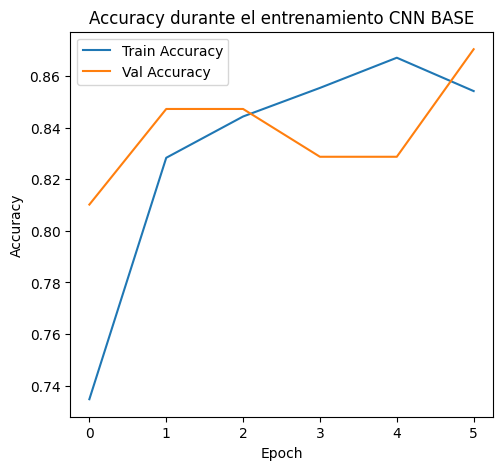

In [140]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento CNN BASE')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_cnn_base.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_cnn_base_validacion": wandb.Image(plt)})
    
plt.legend()

In [141]:
# guardar el modelo entrenado 
base_model.save(f"{dir_artifacts}/best_cnn_base_model.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [142]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = base_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 0s 3ms/step
Accuracy: 0.8101851851851852
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.71      0.83      0.77         6
          Normal       0.78      0.81      0.79        90
         Suspect       0.82      0.78      0.80       105

        accuracy                           0.81       216
       macro avg       0.83      0.86      0.84       216
    weighted avg       0.81      0.81      0.81       216



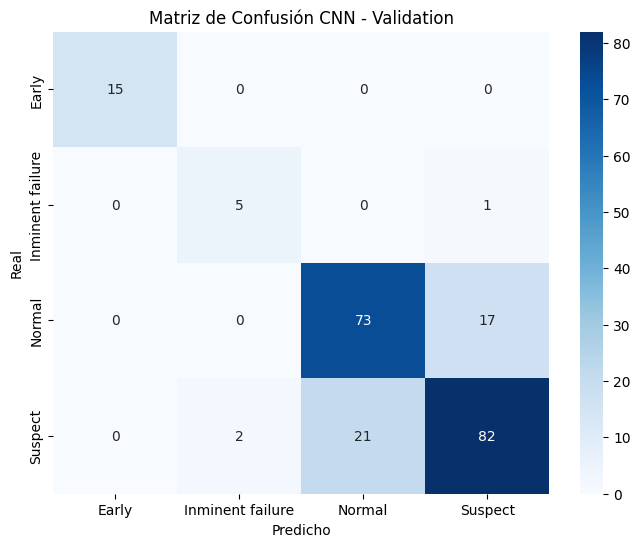

In [143]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_cnn_base_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_cnn_base_validation": wandb.Image(plt)})
    
plt.show()

## Evaluacion - Test

### 1st_test (subconjunto 10%)
Se empleo el subconjunto 10% del dataset empleado para el entrenamiento

In [144]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = base_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 5ms/step
Accuracy: 0.8148148148148148
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.47      0.73      0.57        11
          Normal       0.81      0.82      0.82       180
         Suspect       0.83      0.79      0.81       211

        accuracy                           0.81       432
       macro avg       0.77      0.83      0.79       432
    weighted avg       0.82      0.81      0.82       432



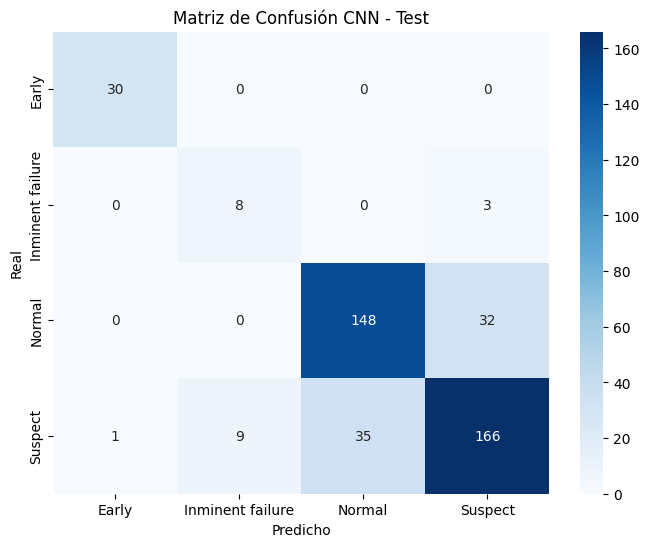

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN BASE - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_cnn_base_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_cnn_base_test": wandb.Image(plt)})
    
plt.show()

### 2_test
Se empleo el dataset 2nd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [146]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_2nd_test_pred = base_model.predict(X_2nd_test)
y_2nd_test_pred = np.argmax(y_2nd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_2nd_test, y_2nd_test_pred))

print(classification_report(
    y_2nd_test,
    y_2nd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_2nd_test, y_2nd_test_pred, average='weighted')

    wandb.log({
        "2nd_test/precision": precision,
        "2nd_test/recall": recall,
        "2nd_test/f1_score": f1
    })



31/31 [==============================] - 0s 2ms/step
Accuracy: 0.5020325203252033
                  precision    recall  f1-score   support

           Early       0.00      0.00      0.00        55
Inminent failure       0.10      0.86      0.18        14
          Normal       0.63      0.43      0.51       458
         Suspect       0.52      0.63      0.57       457

        accuracy                           0.50       984
       macro avg       0.31      0.48      0.31       984
    weighted avg       0.54      0.50      0.50       984



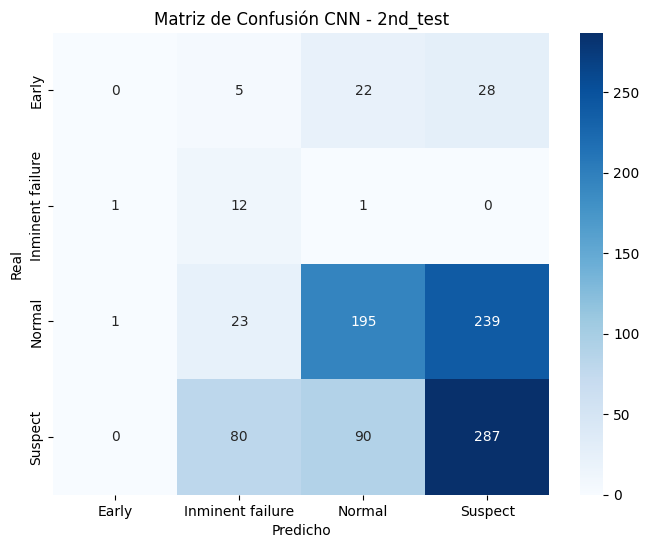

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_2nd_test, y_2nd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN BASE - 2nd_test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_cnn_base_2nd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_cnn_base_2nd_test": wandb.Image(plt)})
    
plt.show()

### 3rd_test
Se empleo el dataset 3rd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [148]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_3rd_test_pred = base_model.predict(X_3rd_test)
y_3rd_test_pred = np.argmax(y_3rd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_3rd_test, y_3rd_test_pred))

print(classification_report(
    y_3rd_test,
    y_3rd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_3rd_test, y_3rd_test_pred, average='weighted')

    wandb.log({
        "3rd_test/precision": precision,
        "3rd_test/recall": recall,
        "3rd_test/f1_score": f1
    })

198/198 [==============================] - 0s 2ms/step
Accuracy: 0.7556925996204934
                  precision    recall  f1-score   support

           Early       0.02      0.00      0.00       476
Inminent failure       0.22      0.91      0.35       131
          Normal       0.92      0.84      0.87      5376
         Suspect       0.20      0.48      0.28       341

        accuracy                           0.76      6324
       macro avg       0.34      0.56      0.38      6324
    weighted avg       0.80      0.76      0.77      6324



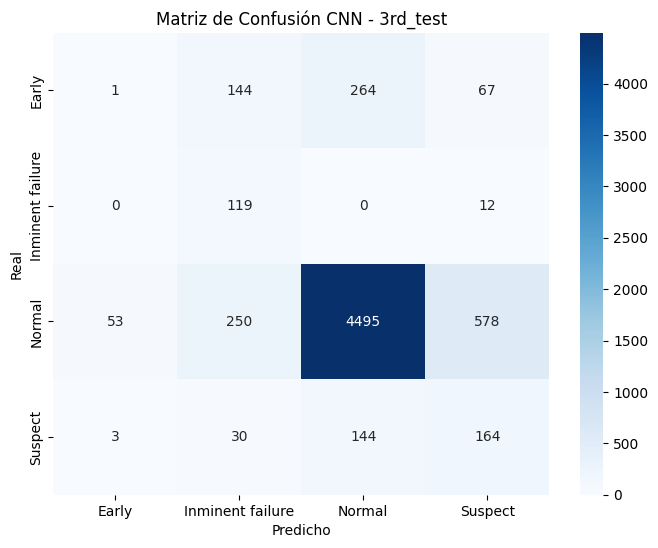

In [149]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_3rd_test, y_3rd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN BASE - 3rd_test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_cnn_base_3rd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_cnn_base_3rd_test": wandb.Image(plt)})
    
plt.show()

In [150]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()


if usar_dataset_base:
    # Recuperar referencias de los datasets originales antes de usar el dataset base
    X_train, y_train, X_valid, y_valid, X_test, y_test = X_train_temp, y_train_temp, X_valid_temp, y_valid_temp, X_test_temp, y_test_temp


2nd_test/f1_score,▁
2nd_test/precision,▁
2nd_test/recall,▁
3rd_test/f1_score,▁
3rd_test/precision,▁
3rd_test/recall,▁
test/f1_score,▁
test/precision,▁
test/recall,▁
validation/f1_score,▁
+2,...


# MK_CNN - large


In [166]:

def make_build_model(X, num_classes):
    def build_model(hp):
        # 1. Definimos las opciones de activación y padding que compartiremos o probaremos individualmente
        # Para activación probamos 'relu' (estándar) y 'tanh' (suele funcionar muy bien en señales de vibración)
        activation_choice = hp.Choice('activation_layers', values=['relu', 'tanh'])
        
        # Para padding probamos 'same' (mantiene la longitud rellenando con ceros) y 'valid' (sin relleno, reduce tamaño)
        padding_choice = hp.Choice('padding_layers', values=['same', 'valid'])

        model = Sequential([
            Conv1D(
                filters=hp.Int('filters_1', min_value=128, max_value=256, step=16),
                kernel_size=hp.Choice('kernel_size_1', values=[2, 3, 5]),
                activation=activation_choice,  # <-- Ahora es dinámico
                padding=padding_choice,        # <-- Ahora es dinámico
                input_shape=(X.shape[1], X.shape[2])
            ),
            MaxPooling1D(pool_size=2),
            Conv1D(
                filters=hp.Int('filters_2', min_value=128, max_value=512, step=32),
                kernel_size=hp.Choice('kernel_size_2', values=[2, 3, 5]),
                activation=activation_choice,  # <-- Usa la misma activación elegida arriba (o puedes crear 'activation_2')
                padding=padding_choice         # <-- Usa el mismo padding elegido arriba
            ),
            Flatten(),
            Dense(
                units=hp.Int('dense_units', min_value=64, max_value=512, step=32),
                activation=activation_choice   # <-- También optimiza la activación de la capa densa
            ),
            Dropout(
                rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
            ),
            Dense(num_classes, activation="softmax") # Esta se queda en softmax sí o sí para la salida multiclase
        ])
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss='sparse_categorical_crossentropy',
            metrics=[
            "accuracy", 
            SparseRecallMacro(num_classes=num_classes), 
            F1MacroScore(num_classes=num_classes)
            ]
        )
        return model
    return build_model

# eval_metric = "val_f1_score" 
eval_metric = "recall_macro" 

tuner = kt.Hyperband(
    make_build_model(X_train, len(np.unique(y_train))),  
    objective=kt.Objective(eval_metric, direction='max'),
    max_epochs=40,
    factor=3,
    directory=f'{dir_artifacts}/kt_cnn_results',
    project_name='cnn_large'
)

# Callback para detener early si no mejora
stop_early_monitor = 'val_loss'  
stop_early = tf.keras.callbacks.EarlyStopping(monitor=stop_early_monitor, patience=5)

# Búsqueda de hiperparámetros
tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

# Ver resumen de los mejores resultados
tuner.results_summary()

# Obtener el mejor modelo
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  filters_1:   {best_hps.get('filters_1')}
  filters_2:   {best_hps.get('filters_2')}
  kernel_1:    {best_hps.get('kernel_size_1')}
  kernel_2:    {best_hps.get('kernel_size_2')}
  dense_units: {best_hps.get('dense_units')}
  dropout:     {best_hps.get('dropout')}
  lr:          {best_hps.get('lr')}
""")

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in best_hps.values.items()}
    config_params["param_metrica_evaluacion"] = eval_metric
    config_params["param_metrica_monitoreo"] = stop_early_monitor
    config_params["param_stop_early_monitor"] = stop_early_monitor


Trial 74 Complete [00h 00m 01s]

Best recall_macro So Far: 0.9438461661338806
Total elapsed time: 00h 11m 09s
Results summary
Results in artefactos/artefactos_train_arq_v1/kt_cnn_results/cnn_large
Showing 10 best trials
Objective(name="recall_macro", direction="max")

Trial 0068 summary
Hyperparameters:
activation_layers: relu
padding_layers: same
filters_1: 160
kernel_size_1: 2
filters_2: 416
kernel_size_2: 3
dense_units: 288
dropout: 0.2
lr: 0.0004251982974278177
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0064
Score: 0.9438461661338806

Trial 0067 summary
Hyperparameters:
activation_layers: relu
padding_layers: valid
filters_1: 160
kernel_size_1: 3
filters_2: 416
kernel_size_2: 2
dense_units: 320
dropout: 0.30000000000000004
lr: 0.0001333046266612092
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0060
Score: 0.9300000071525574

Trial 0057 summary
Hyperparameters:
activation_layers: relu
padding_la

In [167]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones_comparacion2",
        name=f"CNN_LARGE_Agregados_v6_{timestap_str}",
        tags=["cnn_large", "hyperparameter_tuning", "precision_macro"],
        config={**config_params, **config_params_dataset}

    )
    wandb.log_artifact(dataset_artifact)
    wandb.log_artifact(figures_artifact)

In [168]:
# Entrenar el modelo final con los mejores hiperparámetros
callbacks_list = [stop_early]

if usar_wandb:
    callbacks_list.append(WandbMetricsLogger())
    callbacks_list.append(WandbModelCheckpoint(
    filepath=f"{dir_artifacts}/best_cnn_large_model.keras", 
    monitor=stop_early_monitor, 
    save_best_only=True,
    load_weights_on_restart=False
))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks_list
)

Epoch 1/40
199/204 [============================>.] - ETA: 0s - loss: 0.5890 - accuracy: 0.7701 - recall_macro: 0.7701 - f1_score: 0.7837

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:2723: UserWarning: Metric SparseRecallMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


204/204 [==============================] - 4s 13ms/step - loss: 0.5870 - accuracy: 0.7729 - recall_macro: 0.7729 - f1_score: 0.7847 - val_loss: 0.4353 - val_accuracy: 0.8565 - val_recall_macro: 0.8565 - val_f1_score: 0.8731
Epoch 2/40
204/204 [==============================] - 2s 11ms/step - loss: 0.3785 - accuracy: 0.8462 - recall_macro: 0.8462 - f1_score: 0.8586 - val_loss: 0.4211 - val_accuracy: 0.8611 - val_recall_macro: 0.8611 - val_f1_score: 0.8689
Epoch 3/40
204/204 [==============================] - 2s 11ms/step - loss: 0.3450 - accuracy: 0.8646 - recall_macro: 0.8646 - f1_score: 0.8866 - val_loss: 0.3524 - val_accuracy: 0.8565 - val_recall_macro: 0.8565 - val_f1_score: 0.8563
Epoch 4/40
204/204 [==============================] - 2s 11ms/step - loss: 0.2981 - accuracy: 0.8855 - recall_macro: 0.8855 - f1_score: 0.9072 - val_loss: 0.3466 - val_accuracy: 0.8472 - val_recall_macro: 0.8472 - val_f1_score: 0.8513
Epoch 5/40
204/204 [==============================] - 2s 10ms/step - lo

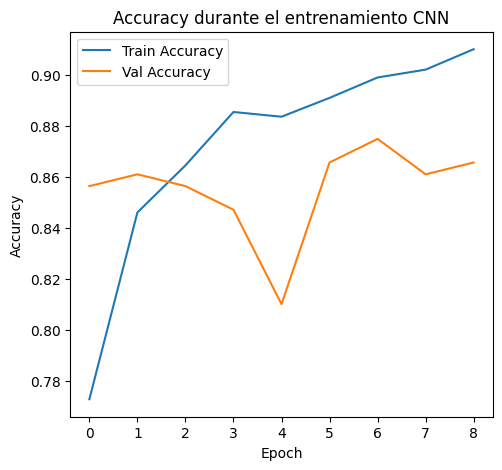

In [169]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento CNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_cnn.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_cnn_validacion": wandb.Image(plt)})
    
plt.legend()

In [170]:
# guardar el modelo entrenado 
best_model.save(f"{dir_artifacts}/best_cnn_large_model.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [171]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 0s 3ms/step
Accuracy: 0.8657407407407407
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.71      0.83      0.77         6
          Normal       0.86      0.84      0.85        90
         Suspect       0.86      0.87      0.86       105

        accuracy                           0.87       216
       macro avg       0.86      0.89      0.87       216
    weighted avg       0.87      0.87      0.87       216



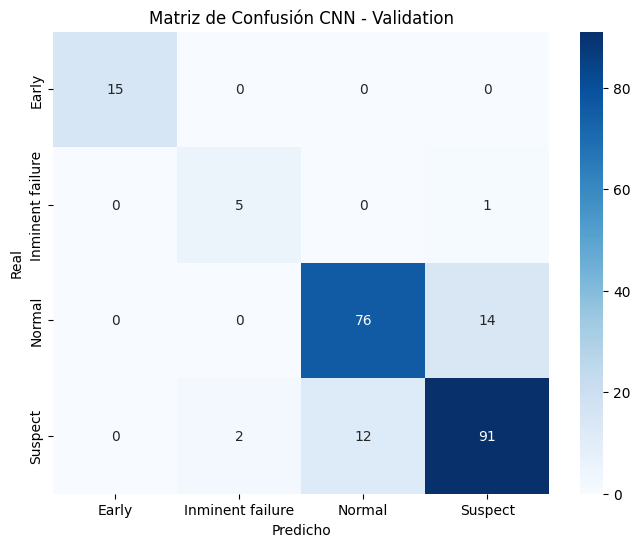

In [172]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN LARGE - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_cnn_large_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_cnn_large_validation": wandb.Image(plt)})
    
plt.show()

## Evaluacion - Test

### 1st_test (subconjunto 10%)
Se empleo el subconjunto 10% del dataset empleado para el entrenamiento

In [173]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 3ms/step
Accuracy: 0.8634259259259259
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.62      0.73      0.67        11
          Normal       0.85      0.88      0.86       180
         Suspect       0.88      0.84      0.86       211

        accuracy                           0.86       432
       macro avg       0.83      0.86      0.84       432
    weighted avg       0.86      0.86      0.86       432



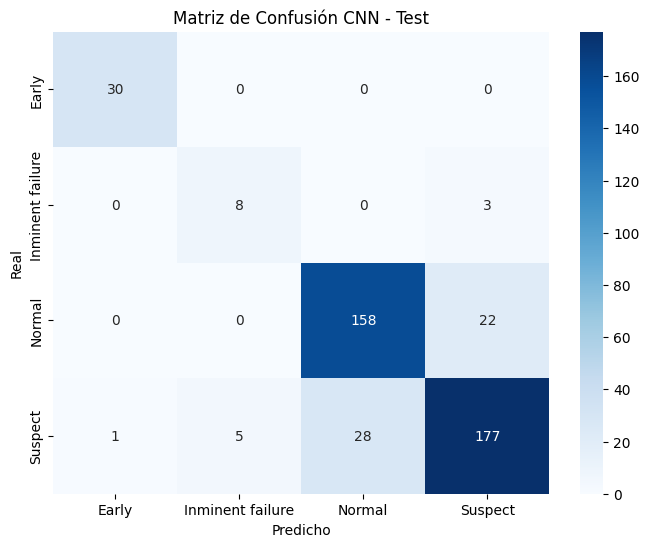

In [174]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN LARGE - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_cnn_large_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_cnn_large_test": wandb.Image(plt)})
    
plt.show()

### 2_test
Se empleo el dataset 2nd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [175]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_2nd_test_pred = best_model.predict(X_2nd_test)
y_2nd_test_pred = np.argmax(y_2nd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_2nd_test, y_2nd_test_pred))

print(classification_report(
    y_2nd_test,
    y_2nd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_2nd_test, y_2nd_test_pred, average='weighted')

    wandb.log({
        "2nd_test/precision": precision,
        "2nd_test/recall": recall,
        "2nd_test/f1_score": f1
    })



31/31 [==============================] - 0s 3ms/step
Accuracy: 0.28353658536585363
                  precision    recall  f1-score   support

           Early       0.00      0.00      0.00        55
Inminent failure       0.06      0.86      0.12        14
          Normal       0.34      0.09      0.15       458
         Suspect       0.34      0.49      0.40       457

        accuracy                           0.28       984
       macro avg       0.19      0.36      0.17       984
    weighted avg       0.32      0.28      0.26       984



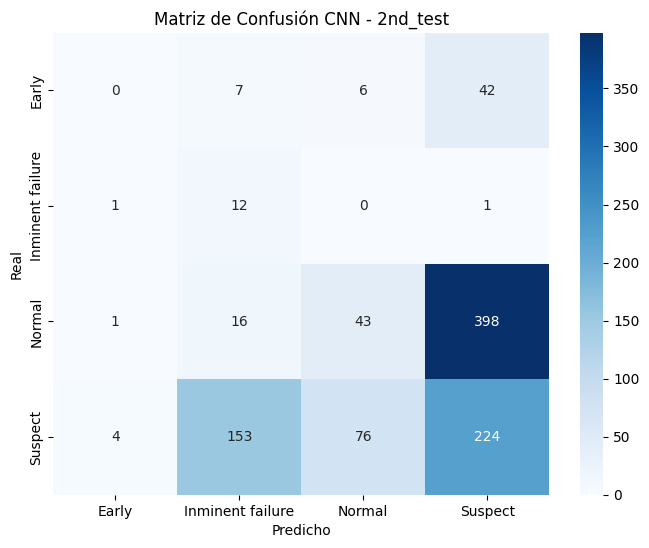

In [176]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_2nd_test, y_2nd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN LARGE - 2nd_test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_cnn_large_2nd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_cnn_large_2nd_test": wandb.Image(plt)})
    
plt.show()

### 3rd_test
Se empleo el dataset 3rd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [177]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_3rd_test_pred = best_model.predict(X_3rd_test)
y_3rd_test_pred = np.argmax(y_3rd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_3rd_test, y_3rd_test_pred))

print(classification_report(
    y_3rd_test,
    y_3rd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_3rd_test, y_3rd_test_pred, average='weighted')

    wandb.log({
        "3rd_test/precision": precision,
        "3rd_test/recall": recall,
        "3rd_test/f1_score": f1
    })

198/198 [==============================] - 1s 3ms/step
Accuracy: 0.7251739405439596
                  precision    recall  f1-score   support

           Early       0.02      0.00      0.01       476
Inminent failure       0.28      0.99      0.43       131
          Normal       0.90      0.81      0.85      5376
         Suspect       0.13      0.35      0.18       341

        accuracy                           0.73      6324
       macro avg       0.33      0.54      0.37      6324
    weighted avg       0.78      0.73      0.74      6324



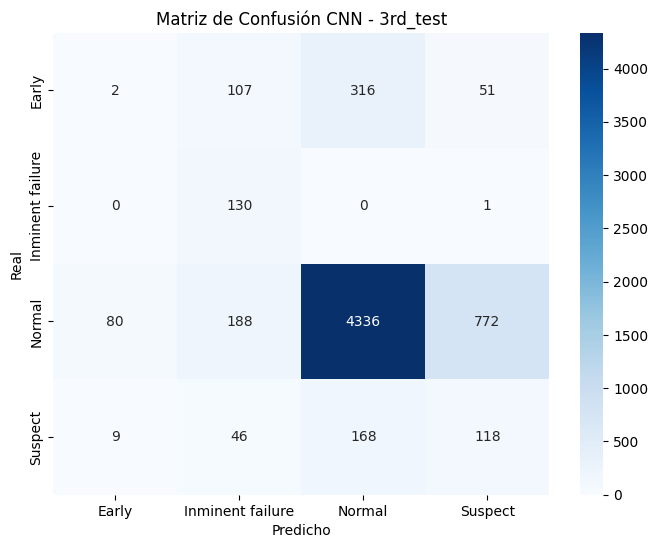

In [178]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_3rd_test, y_3rd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN LARGE - 3rd_test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_cnn_large_3rd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_cnn_large_3rd_test": wandb.Image(plt)})
    
plt.show()

In [179]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

2nd_test/f1_score,▁
2nd_test/precision,▁
2nd_test/recall,▁
3rd_test/f1_score,▁
3rd_test/precision,▁
3rd_test/recall,▁
epoch/accuracy,▁▅▆▇▇▇▇██
epoch/epoch,▁▂▃▄▅▅▆▇█
epoch/f1_score,▁▅▆▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁
+12,...


# Fuzzy CNN


In [58]:

def make_build_model(X, num_classes):
    def build_model(hp):
        # Opciones dinámicas de activación y padding para las capas convolucionales
        activation_choice = hp.Choice('activation_layers', values=['relu', 'tanh'])
        # padding_choice = hp.Choice('padding_layers', values=['same', 'valid'])
        padding_choice = "same"
        
        # Hiperparámetro nuevo: Probamos si funciona mejor con 3, 4 o 5 conjuntos difusos
        fuzzy_sets_choice = hp.Choice('num_fuzzy_sets', values=[ 5,6,7])

        # Calculamos el total de características de entrada al aplanar el paso temporal si viene en 3D
        # Si X ya es plano (batch, features), puedes usar simplemente X.shape[1]
        total_features = X.shape[1] * X.shape[2]

        model = Sequential([
            # Aseguramos la forma de entrada y aplanamos a vector para la transformación difusa
            Input(shape=(X.shape[1], X.shape[2])),
            Flatten(), 
            
            # Capa de conversión Difusa (Pasa de vector a matriz de pertenencia)
            FuzzyMembershipLayer(num_fuzzy_sets=fuzzy_sets_choice),
            
            # Reshape para añadir el canal de "gris" para que Conv2D pueda procesarlo: (Features, Fuzzy_Sets, 1)
            Reshape((total_features, fuzzy_sets_choice, 1)),

            # Primera Capa Convolucional 2D
            Conv2D(
                filters=hp.Int('filters_1', min_value=48, max_value=144, step=16),
                # El kernel se mueve verticalmente sobre las características
                kernel_size=hp.Choice('kernel_size_1', values=[3, 5, 7]),
                activation=activation_choice,
                padding=padding_choice
            ),
            
            # Segunda Capa Convolucional 2D
            Conv2D(
                filters=hp.Int('filters_2', min_value=224, max_value=320, step=32),
                kernel_size=hp.Choice('kernel_size_2', values=[ 5,7]),
                activation=activation_choice,
                padding=padding_choice
            ),
            
            Flatten(),
            
            # Capa Densa Intermedia
            Dense(
                units=hp.Int('dense_units', min_value=224, max_value=320, step=32),
                activation=activation_choice
            ),
            
            # Regularización
            Dropout(
                rate=hp.Float('dropout', min_value=0.05, max_value=0.1, step=0.1)
            ),
            
            # Salida clasificador
            Dense(num_classes, activation="softmax")
        ])
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-2, max_value=0.1, sampling='log')
            ),
            loss='sparse_categorical_crossentropy',
            metrics=[
                "accuracy", 
                SparseRecallMacro(num_classes=num_classes), 
                F1MacroScore(num_classes=num_classes)
            ]
        )
        return model
    return build_model
# eval_metric = "val_f1_score" 
eval_metric = "recall_macro" 

tuner = kt.Hyperband(
    make_build_model(X_train, len(np.unique(y_train))),  
    objective=kt.Objective(eval_metric, direction='max'),
    max_epochs=40,
    factor=3,
    directory=f'{dir_artifacts}/kt_cnn_results',
    project_name='fuzzy_cnn'
)

# Callback para detener early si no mejora
stop_early_monitor = 'val_loss'  
stop_early = tf.keras.callbacks.EarlyStopping(monitor=stop_early_monitor, patience=5)

# Búsqueda de hiperparámetros
tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

# Ver resumen de los mejores resultados
tuner.results_summary()

# Obtener el mejor modelo
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  filters_1:   {best_hps.get('filters_1')}
  fuzzy_sets: {best_hps.get('num_fuzzy_sets')}
  filters_2:   {best_hps.get('filters_2')}
  kernel_1:    {best_hps.get('kernel_size_1')}
  kernel_2:    {best_hps.get('kernel_size_2')}
  dense_units: {best_hps.get('dense_units')}
  dropout:     {best_hps.get('dropout')}
  lr:          {best_hps.get('lr')}
""")

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in best_hps.values.items()}
    config_params["param_metrica_evaluacion"] = eval_metric
    config_params["param_metrica_monitoreo"] = stop_early_monitor
    config_params["param_stop_early_monitor"] = stop_early_monitor


Reloading Tuner from artefactos/artefactos_train_arq_v1/kt_cnn_results/fuzzy_cnn/tuner0.json
Results summary
Results in artefactos/artefactos_train_arq_v1/kt_cnn_results/fuzzy_cnn
Showing 10 best trials
Objective(name="recall_macro", direction="max")

Trial 0082 summary
Hyperparameters:
activation_layers: relu
num_fuzzy_sets: 5
filters_1: 48
kernel_size_1: 3
filters_2: 224
kernel_size_2: 5
dense_units: 224
dropout: 0.1
lr: 0.002009960004291021
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0078
Score: 0.9415384531021118

Trial 0073 summary
Hyperparameters:
activation_layers: relu
num_fuzzy_sets: 4
filters_1: 48
kernel_size_1: 3
filters_2: 224
kernel_size_2: 5
dense_units: 256
dropout: 0.1
lr: 0.0004998548783416624
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0067
Score: 0.9399999976158142

Trial 0072 summary
Hyperparameters:
activation_layers: relu
num_fuzzy_sets: 3
filters_1: 64
kernel_size_1: 3
filt

In [59]:
{f"param_{k}": v for k, v in best_hps.values.items()}

{'param_activation_layers': 'relu',
 'param_num_fuzzy_sets': 5,
 'param_filters_1': 48,
 'param_kernel_size_1': 3,
 'param_filters_2': 224,
 'param_kernel_size_2': 5,
 'param_dense_units': 224,
 'param_dropout': 0.1,
 'param_lr': 0.002009960004291021,
 'param_tuner/epochs': 40,
 'param_tuner/initial_epoch': 14,
 'param_tuner/bracket': 1,
 'param_tuner/round': 1,
 'param_tuner/trial_id': '0078'}

In [60]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones_comparacion2",
        name=f"FUZZY_CNN_Agregados_v6_{timestap_str}",
        tags=["fuzzy_cnn", "hyperparameter_tuning", "recall_macro"],
        config={**config_params, **config_params_dataset}

    )
    wandb.log_artifact(dataset_artifact)
    wandb.log_artifact(figures_artifact)

wandb: WARNING Artifact "run_avqm1v7p_model" already exists with the same content. No new version will be created.


In [61]:
# Entrenar el modelo final con los mejores hiperparámetros
callbacks_list = [stop_early]

if usar_wandb:
    callbacks_list.append(WandbMetricsLogger())
    callbacks_list.append(WandbModelCheckpoint(
    filepath=f"{dir_artifacts}/best_fuzzy_cnn_model.keras", 
    monitor=stop_early_monitor, 
    save_best_only=True,
    load_weights_on_restart=False
))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks_list
)

Epoch 1/40
204/204 [==============================] - ETA: 0s - loss: 0.7766 - accuracy: 0.6732 - recall_macro: 0.6732 - f1_score: 0.7118

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:2723: UserWarning: Metric SparseRecallMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


204/204 [==============================] - 32s 140ms/step - loss: 0.7766 - accuracy: 0.6732 - recall_macro: 0.6732 - f1_score: 0.7118 - val_loss: 0.5438 - val_accuracy: 0.7917 - val_recall_macro: 0.7917 - val_f1_score: 0.8177
Epoch 2/40
204/204 [==============================] - 26s 128ms/step - loss: 0.4377 - accuracy: 0.7975 - recall_macro: 0.7975 - f1_score: 0.8399 - val_loss: 0.5647 - val_accuracy: 0.7639 - val_recall_macro: 0.7639 - val_f1_score: 0.7891
Epoch 3/40
204/204 [==============================] - 27s 134ms/step - loss: 0.3772 - accuracy: 0.8338 - recall_macro: 0.8338 - f1_score: 0.8712 - val_loss: 0.4459 - val_accuracy: 0.8241 - val_recall_macro: 0.8241 - val_f1_score: 0.8477
Epoch 4/40
204/204 [==============================] - 28s 135ms/step - loss: 0.3537 - accuracy: 0.8498 - recall_macro: 0.8498 - f1_score: 0.8846 - val_loss: 0.4411 - val_accuracy: 0.8056 - val_recall_macro: 0.8056 - val_f1_score: 0.8523
Epoch 5/40
204/204 [==============================] - 27s 130ms

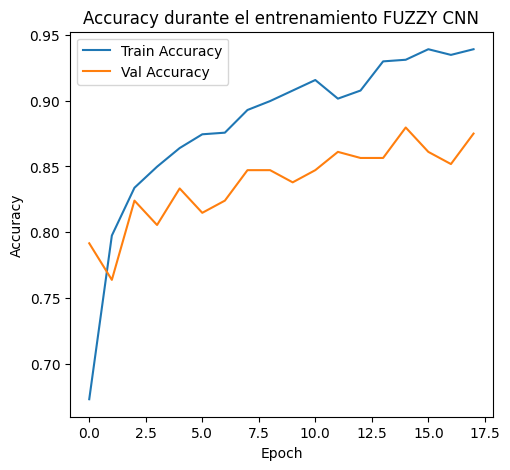

In [62]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento FUZZY CNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_fuzzy_cnnn.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_fuzzy_cnn_validacion": wandb.Image(plt)})
    
plt.legend()

In [63]:
# guardar el modelo entrenado 
best_model.save(f"{dir_artifacts}/best_fuzzy_cnn_model.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [64]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 0s 30ms/step
Accuracy: 0.875
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       1.00      0.83      0.91         6
          Normal       0.97      0.73      0.84        90
         Suspect       0.80      0.98      0.88       105

        accuracy                           0.88       216
       macro avg       0.94      0.89      0.91       216
    weighted avg       0.89      0.88      0.87       216



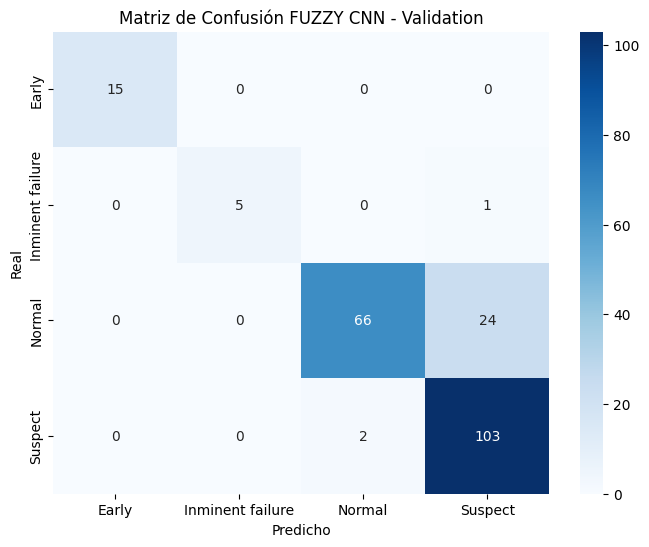

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión FUZZY CNN - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_fuzzy_cnn_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_fuzzy_cnn_validation": wandb.Image(plt)})
    
plt.show()

## Evaluacion - Test

### 1st_test (subconjunto 10%)
Se empleo el subconjunto 10% del dataset empleado para el entrenamiento

In [66]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 21ms/step
Accuracy: 0.8379629629629629
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.89      0.73      0.80        11
          Normal       0.90      0.72      0.80       180
         Suspect       0.79      0.92      0.85       211

        accuracy                           0.84       432
       macro avg       0.88      0.84      0.86       432
    weighted avg       0.85      0.84      0.84       432



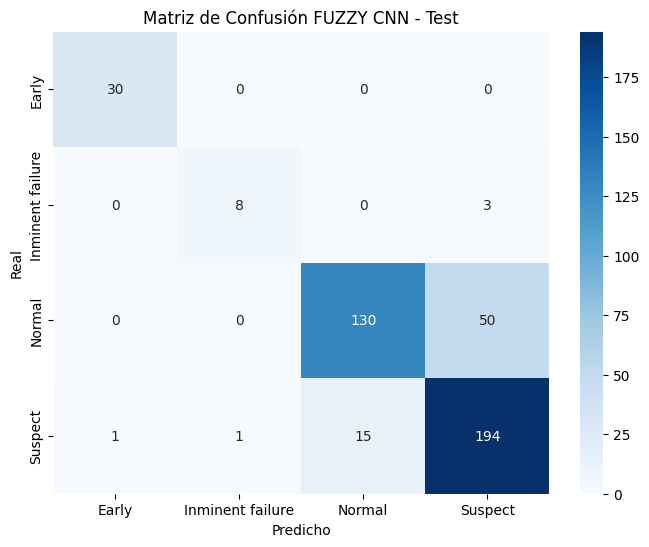

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión FUZZY CNN - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_fuzzy_cnn_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_fuzzy_cnn_test": wandb.Image(plt)})
    
plt.show()

### 2_test
Se empleo el dataset 2nd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [68]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_2nd_test_pred = best_model.predict(X_2nd_test)
y_2nd_test_pred = np.argmax(y_2nd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_2nd_test, y_2nd_test_pred))

print(classification_report(
    y_2nd_test,
    y_2nd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_2nd_test, y_2nd_test_pred, average='weighted')

    wandb.log({
        "2nd_test/precision": precision,
        "2nd_test/recall": recall,
        "2nd_test/f1_score": f1
    })



31/31 [==============================] - 1s 22ms/step
Accuracy: 0.4166666666666667
                  precision    recall  f1-score   support

           Early       0.25      0.02      0.03        55
Inminent failure       0.07      0.64      0.13        14
          Normal       0.49      0.55      0.52       458
         Suspect       0.43      0.33      0.37       457

        accuracy                           0.42       984
       macro avg       0.31      0.38      0.26       984
    weighted avg       0.44      0.42      0.42       984



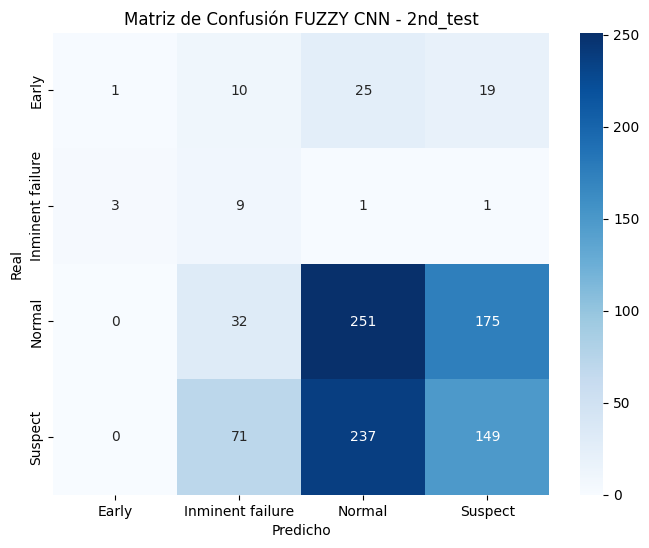

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_2nd_test, y_2nd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión FUZZY CNN - 2nd_test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_fuzzy_cnn_2nd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_fuzzy_cnn_2nd_test": wandb.Image(plt)})
    
plt.show()

### 3rd_test
Se empleo el dataset 3rd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [70]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_3rd_test_pred = best_model.predict(X_3rd_test)
y_3rd_test_pred = np.argmax(y_3rd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_3rd_test, y_3rd_test_pred))

print(classification_report(
    y_3rd_test,
    y_3rd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_3rd_test, y_3rd_test_pred, average='weighted')

    wandb.log({
        "3rd_test/precision": precision,
        "3rd_test/recall": recall,
        "3rd_test/f1_score": f1
    })

198/198 [==============================] - 4s 22ms/step
Accuracy: 0.5608791903858318
                  precision    recall  f1-score   support

           Early       0.14      0.00      0.01       476
Inminent failure       0.13      0.61      0.22       131
          Normal       0.91      0.62      0.74      5376
         Suspect       0.07      0.44      0.13       341

        accuracy                           0.56      6324
       macro avg       0.31      0.42      0.27      6324
    weighted avg       0.79      0.56      0.64      6324



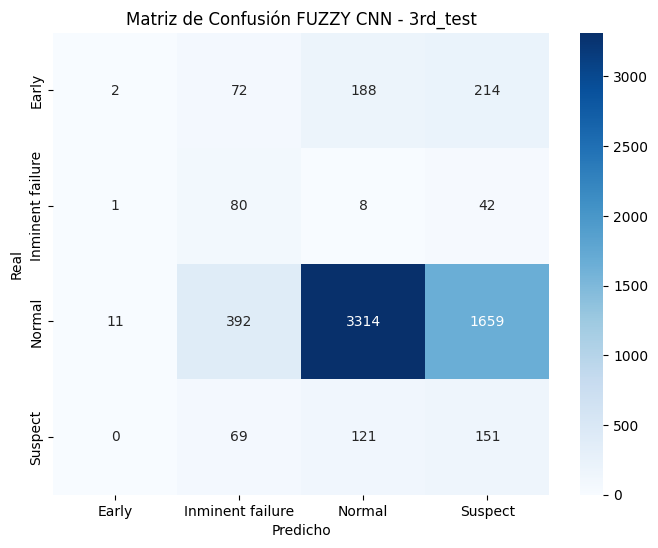

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_3rd_test, y_3rd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión FUZZY CNN - 3rd_test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_fuzzy_cnn_3rd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_fuzzy_cnn_3rd_test": wandb.Image(plt)})
    
plt.show()

In [72]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

2nd_test/f1_score,▁
2nd_test/precision,▁
2nd_test/recall,▁
3rd_test/f1_score,▁
3rd_test/precision,▁
3rd_test/recall,▁
epoch/accuracy,▁▄▅▆▆▆▆▇▇▇▇▇▇█████
epoch/epoch,▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
epoch/f1_score,▁▅▆▆▆▇▇▇▇▇▇▇▇█████
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+12,...


# LSTM - base

In [65]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def make_build_model(X_train, num_classes):
    def build_model(hp):
        model = Sequential([

            LSTM(
                units=hp.Int('lstm_units_1', min_value=32, max_value=256, step=32),
                return_sequences=True,
                input_shape=(X_train.shape[1], X_train.shape[2])
            ),

            Dropout(
                rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
            ),

            LSTM(
                units=hp.Int('lstm_units_2', min_value=16, max_value=128, step=16)
            ),

            Dense(
                units=hp.Int('dense_units', min_value=32, max_value=256, step=32),
                activation="relu"
            ),

            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy",
                # tf.keras.metrics.Precision(name='precision'),
                # tf.keras.metrics.Recall(name='recall'),
                F1MacroScore(num_classes=num_classes)]
        )

        return model
    return build_model

# eval_metric = "val_f1_score"  
eval_metric = "recall" 

tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective(eval_metric, direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='lstm_vibraciones'
)

stop_early_monitor = 'val_loss'  
stop_early = tf.keras.callbacks.EarlyStopping(monitor=stop_early_monitor, patience=5)

# Búsqueda de hiperparámetros
tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  lstm_units_1: {best_hps.get('lstm_units_1')}
  lstm_units_2: {best_hps.get('lstm_units_2')}
  dropout:      {best_hps.get('dropout_1')}
  dense_units:  {best_hps.get('dense_units')}
  lr:           {best_hps.get('lr')}
""")

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in best_hps.values.items()}
    config_params["param_metrica_evaluacion"] = eval_metric
    config_params["param_metrica_monitoreo"] = stop_early_monitor
    config_params["param_stop_early_monitor"] = stop_early_monitor


Reloading Tuner from kt_results/lstm_vibraciones/tuner0.json
Results summary
Results in kt_results/lstm_vibraciones
Showing 10 best trials
Objective(name="recall", direction="max")

Trial 0086 summary
Hyperparameters:
lstm_units_1: 32
dropout_1: 0.4
lstm_units_2: 80
dense_units: 128
lr: 0.008326380697068002
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.957563042640686

Trial 0083 summary
Hyperparameters:
lstm_units_1: 128
dropout_1: 0.1
lstm_units_2: 128
dense_units: 224
lr: 0.0005167397035568562
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0074
Score: 0.9575486779212952

Trial 0084 summary
Hyperparameters:
lstm_units_1: 224
dropout_1: 0.5
lstm_units_2: 16
dense_units: 160
lr: 0.003687492934224323
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0076
Score: 0.9575390219688416

Trial 0082 summary
Hyperparameters:
lstm_units_1: 128
dropout_1: 0.1
lstm_units_2: 128
dense_

In [66]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones_comparacion2",
        name=f"LSTM_agregados_v6_{timestap_str}",
        tags=["lstm", "hyperparameter_tuning", "precision_macro"],
        config={**config_params, **config_params_dataset}
    )
    wandb.log_artifact(dataset_artifact)
    wandb.log_artifact(figures_artifact)

In [67]:
# Entrenar el modelo final con los mejores hiperparámetros
callbacks_list = [stop_early]

if usar_wandb:
    callbacks_list.append(WandbMetricsLogger())
    callbacks_list.append(WandbModelCheckpoint(
    filepath=f"{dir_artifacts}/best_lstm_model.keras", 
    monitor=stop_early_monitor, 
    save_best_only=True,
    load_weights_on_restart=False
))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    # validation_split=0.2,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks_list
)

Epoch 1/40
204/204 [==============================] - 7s 16ms/step - loss: 0.4905 - accuracy: 0.7957 - f1_score: 0.8287 - val_loss: 0.2214 - val_accuracy: 0.9120 - val_f1_score: 0.9177
Epoch 2/40
204/204 [==============================] - 2s 9ms/step - loss: 0.2730 - accuracy: 0.9071 - f1_score: 0.9190 - val_loss: 0.1475 - val_accuracy: 0.9630 - val_f1_score: 0.9322
Epoch 3/40
204/204 [==============================] - 2s 7ms/step - loss: 0.1917 - accuracy: 0.9385 - f1_score: 0.9478 - val_loss: 0.1223 - val_accuracy: 0.9676 - val_f1_score: 0.9489
Epoch 4/40
204/204 [==============================] - 2s 9ms/step - loss: 0.1346 - accuracy: 0.9514 - f1_score: 0.9576 - val_loss: 0.0736 - val_accuracy: 0.9769 - val_f1_score: 0.9658
Epoch 5/40
204/204 [==============================] - 2s 8ms/step - loss: 0.2152 - accuracy: 0.9348 - f1_score: 0.9309 - val_loss: 0.1050 - val_accuracy: 0.9676 - val_f1_score: 0.9430
Epoch 6/40
204/204 [==============================] - 2s 8ms/step - loss: 0.113

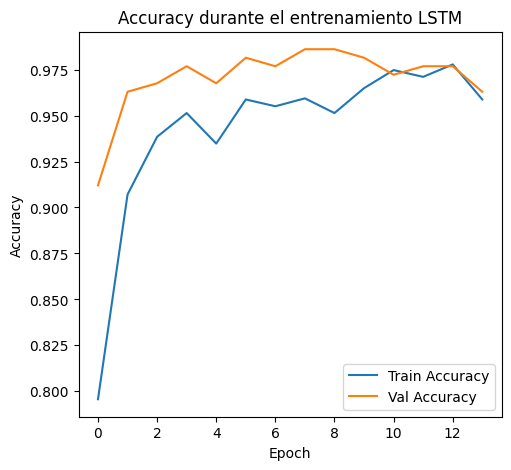

In [68]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento LSTM')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_lstm.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_lstm_validacion": wandb.Image(plt)})
    
plt.legend()

In [69]:
# guardar el modelo entrenado 
best_model.save(f"{dir_artifacts}/best_lstm_model.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [70]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 1s 3ms/step
Accuracy: 0.9629629629629629
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.86      1.00      0.92         6
          Normal       0.94      0.99      0.96        90
         Suspect       0.99      0.93      0.96       105

        accuracy                           0.96       216
       macro avg       0.95      0.98      0.96       216
    weighted avg       0.96      0.96      0.96       216



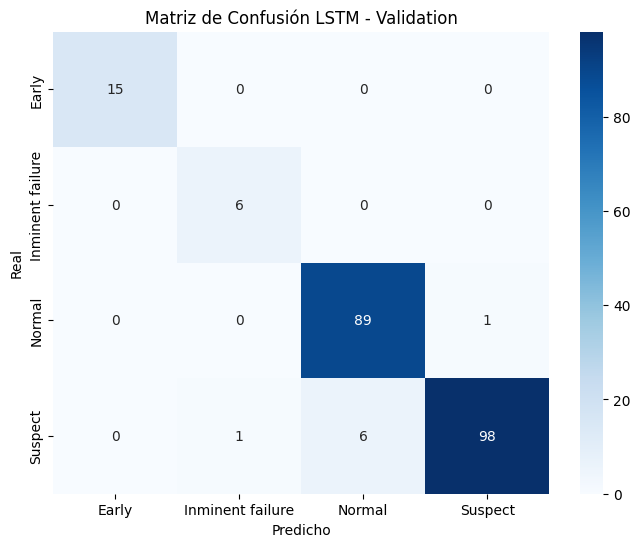

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_lstm_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_lstm_validation": wandb.Image(plt)})
    
plt.show()

## Evaluación - Test

### 1st_test (subconjunto 10%)
Se empleo el subconjunto 10% del dataset empleado para el entrenamiento

In [72]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 3ms/step
Accuracy: 0.9467592592592593
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.92      1.00      0.96        11
          Normal       0.90      1.00      0.94       180
         Suspect       1.00      0.89      0.94       211

        accuracy                           0.95       432
       macro avg       0.94      0.97      0.96       432
    weighted avg       0.95      0.95      0.95       432



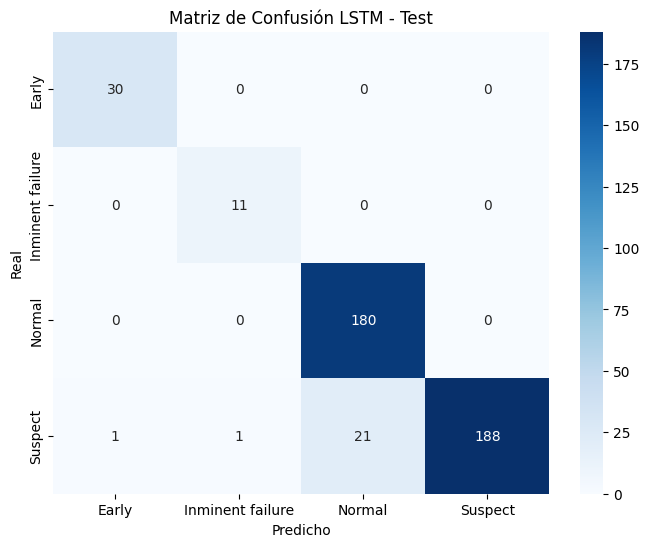

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_lstm_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_lstm_test": wandb.Image(plt)})
    
plt.show()

### 2_test
Se empleo el dataset 2nd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [74]:
y_2nd_test_pred = best_model.predict(X_2nd_test)
y_2nd_test_pred = np.argmax(y_2nd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_2nd_test, y_2nd_test_pred))

print(classification_report(
    y_2nd_test,
    y_2nd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_2nd_test, y_2nd_test_pred, average='weighted')

    wandb.log({
        "2nd_test/precision": precision,
        "2nd_test/recall": recall,
        "2nd_test/f1_score": f1
    })

31/31 [==============================] - 0s 3ms/step
Accuracy: 0.49390243902439024
                  precision    recall  f1-score   support

           Early       0.00      0.00      0.00        55
Inminent failure       0.16      0.86      0.28        14
          Normal       0.51      0.98      0.67       458
         Suspect       0.66      0.05      0.10       457

        accuracy                           0.49       984
       macro avg       0.33      0.47      0.26       984
    weighted avg       0.55      0.49      0.36       984



/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels w

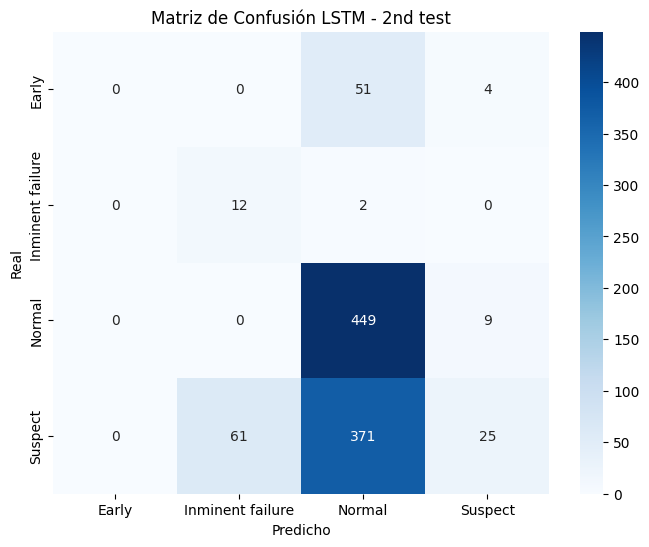

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_2nd_test, y_2nd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM - 2nd test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_lstm_2nd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_lstm_2nd_test": wandb.Image(plt)})
    
plt.show()

### 3rd_test
Se empleo el dataset 3rd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [76]:
y_3rd_test_pred = best_model.predict(X_3rd_test)
y_3rd_test_pred = np.argmax(y_3rd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_3rd_test, y_3rd_test_pred))

print(classification_report(
    y_3rd_test,
    y_3rd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_3rd_test, y_3rd_test_pred, average='weighted')

    wandb.log({
        "3rd_test/precision": precision,
        "3rd_test/recall": recall,
        "3rd_test/f1_score": f1
    })

198/198 [==============================] - 1s 3ms/step
Accuracy: 0.7661290322580645
                  precision    recall  f1-score   support

           Early       0.00      0.00      0.00       476
Inminent failure       0.56      0.97      0.71       131
          Normal       0.91      0.86      0.89      5376
         Suspect       0.09      0.28      0.14       341

        accuracy                           0.77      6324
       macro avg       0.39      0.53      0.43      6324
    weighted avg       0.79      0.77      0.77      6324



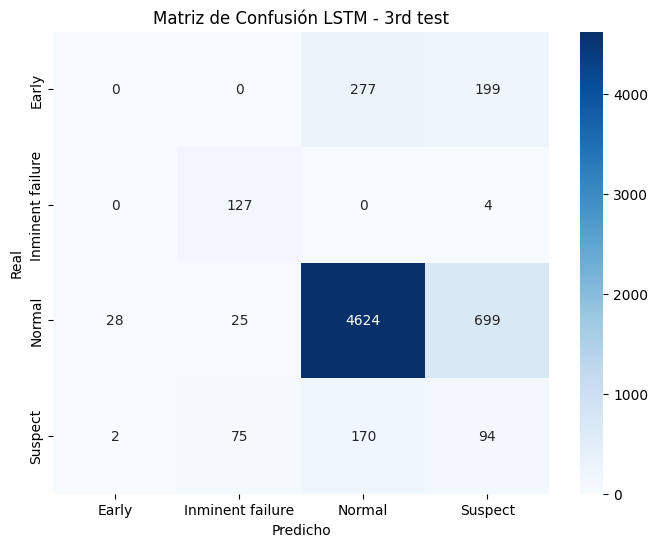

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_3rd_test, y_3rd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM - 3rd test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_lstm_3rd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_lstm_3rd_test": wandb.Image(plt)})
    
plt.show()

In [78]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

2nd_test/f1_score,▁
2nd_test/precision,▁
2nd_test/recall,▁
3rd_test/f1_score,▁
3rd_test/precision,▁
3rd_test/recall,▁
epoch/accuracy,▁▅▆▇▆▇▇▇▇████▇
epoch/epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
epoch/f1_score,▁▅▆▇▆▇▇▇▇████▇
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+10,...


# LSTM - large
se duplico los tamaño de las capa con respecto al LSMT - base

In [79]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def make_build_model(X_train, num_classes):
    def build_model(hp):
        model = Sequential([

            # Primera capa LSTM (Rango aumentado de 64 a 512)
            LSTM(
                units=hp.Int('lstm_units_1', min_value=64, max_value=512, step=64),
                return_sequences=True,
                input_shape=(X_train.shape[1], X_train.shape[2])
            ),

            # Rango de Dropout ligeramente ampliado para prevenir overfitting en celdas grandes
            Dropout(
                rate=hp.Float('dropout_1', min_value=0.1, max_value=0.6, step=0.1)
            ),

            # Segunda capa LSTM (Rango aumentado de 32 a 256)
            LSTM(
                units=hp.Int('lstm_units_2', min_value=32, max_value=256, step=32)
            ),

            # Capa Densa (Rango aumentado de 64 a 512)
            Dense(
                units=hp.Int('dense_units', min_value=64, max_value=512, step=64),
                activation="relu"
            ),

            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy", F1MacroScore(num_classes=num_classes)]
        )

        return model
    return build_model


# eval_metric = "val_f1_score"  
eval_metric = "recall" 

tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective(eval_metric, direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='lstm_vibraciones'
)

stop_early_monitor = 'val_loss'  
stop_early = tf.keras.callbacks.EarlyStopping(monitor=stop_early_monitor, patience=5)

# Búsqueda de hiperparámetros
tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  lstm_units_1: {best_hps.get('lstm_units_1')}
  lstm_units_2: {best_hps.get('lstm_units_2')}
  dropout:      {best_hps.get('dropout_1')}
  dense_units:  {best_hps.get('dense_units')}
  lr:           {best_hps.get('lr')}
""")

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in best_hps.values.items()}
    config_params["param_metrica_evaluacion"] = eval_metric
    config_params["param_metrica_monitoreo"] = stop_early_monitor
    config_params["param_stop_early_monitor"] = stop_early_monitor


Reloading Tuner from kt_results/lstm_vibraciones/tuner0.json
Results summary
Results in kt_results/lstm_vibraciones
Showing 10 best trials
Objective(name="recall", direction="max")

Trial 0086 summary
Hyperparameters:
lstm_units_1: 32
dropout_1: 0.4
lstm_units_2: 80
dense_units: 128
lr: 0.008326380697068002
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.957563042640686

Trial 0083 summary
Hyperparameters:
lstm_units_1: 128
dropout_1: 0.1
lstm_units_2: 128
dense_units: 224
lr: 0.0005167397035568562
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0074
Score: 0.9575486779212952

Trial 0084 summary
Hyperparameters:
lstm_units_1: 224
dropout_1: 0.5
lstm_units_2: 16
dense_units: 160
lr: 0.003687492934224323
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0076
Score: 0.9575390219688416

Trial 0082 summary
Hyperparameters:
lstm_units_1: 128
dropout_1: 0.1
lstm_units_2: 128
dense_

In [80]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones_comparacion2",
        name=f"LSTM_LARGE_agregados_v6_{timestap_str}",
        tags=["lstm", "large" ],
        config={**config_params, **config_params_dataset}
    )
    wandb.log_artifact(dataset_artifact)
    wandb.log_artifact(figures_artifact)

In [81]:
# Entrenar el modelo final con los mejores hiperparámetros
callbacks_list = [stop_early]

if usar_wandb:
    callbacks_list.append(WandbMetricsLogger())
    callbacks_list.append(WandbModelCheckpoint(
    filepath=f"{dir_artifacts}/best_lstm_large_model.keras", 
    monitor=stop_early_monitor, 
    save_best_only=True,
    load_weights_on_restart=False
))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    # validation_split=0.2,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks_list
)

Epoch 1/40
204/204 [==============================] - 6s 12ms/step - loss: 0.4233 - accuracy: 0.8308 - f1_score: 0.8557 - val_loss: 0.1114 - val_accuracy: 0.9676 - val_f1_score: 0.9348
Epoch 2/40
204/204 [==============================] - 2s 9ms/step - loss: 0.2437 - accuracy: 0.9200 - f1_score: 0.9293 - val_loss: 0.1072 - val_accuracy: 0.9722 - val_f1_score: 0.9515
Epoch 3/40
204/204 [==============================] - 2s 11ms/step - loss: 0.1843 - accuracy: 0.9342 - f1_score: 0.9473 - val_loss: 0.1112 - val_accuracy: 0.9630 - val_f1_score: 0.9581
Epoch 4/40
204/204 [==============================] - 2s 11ms/step - loss: 0.1833 - accuracy: 0.9385 - f1_score: 0.9459 - val_loss: 0.1174 - val_accuracy: 0.9676 - val_f1_score: 0.9820
Epoch 5/40
204/204 [==============================] - 2s 11ms/step - loss: 0.1390 - accuracy: 0.9563 - f1_score: 0.9618 - val_loss: 0.1003 - val_accuracy: 0.9769 - val_f1_score: 0.9541
Epoch 6/40
204/204 [==============================] - 2s 9ms/step - loss: 0.

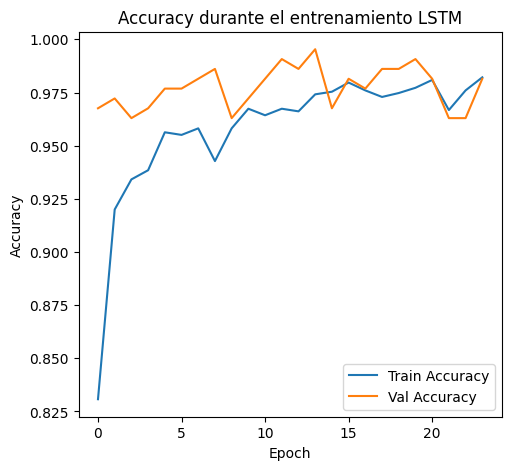

In [82]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento LSTM')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_lstm_large.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_lstm_large_validacion": wandb.Image(plt)})
    
plt.legend()

In [83]:
# guardar el modelo entrenado 
best_model.save(f"{dir_artifacts}/best_lstm_large_model.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [84]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 1s 3ms/step
Accuracy: 0.9814814814814815
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.71      0.83      0.77         6
          Normal       1.00      0.99      0.99        90
         Suspect       0.98      0.98      0.98       105

        accuracy                           0.98       216
       macro avg       0.92      0.95      0.94       216
    weighted avg       0.98      0.98      0.98       216



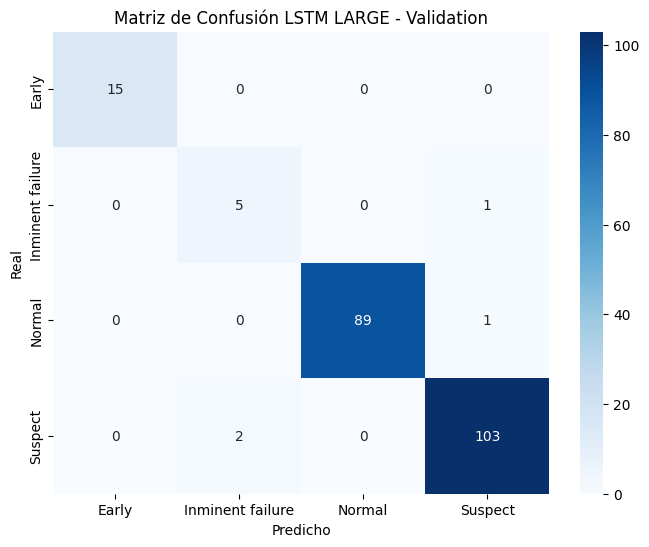

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM LARGE - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_lstm_large_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_lstm_large_validation": wandb.Image(plt)})
    
plt.show()

## Evaluación - Test

### 1st_test (subconjunto 10%)
Se empleo el subconjunto 10% del dataset empleado para el entrenamiento

In [86]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 3ms/step
Accuracy: 0.9791666666666666
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       1.00      0.91      0.95        11
          Normal       0.97      0.99      0.98       180
         Suspect       0.99      0.97      0.98       211

        accuracy                           0.98       432
       macro avg       0.98      0.97      0.97       432
    weighted avg       0.98      0.98      0.98       432



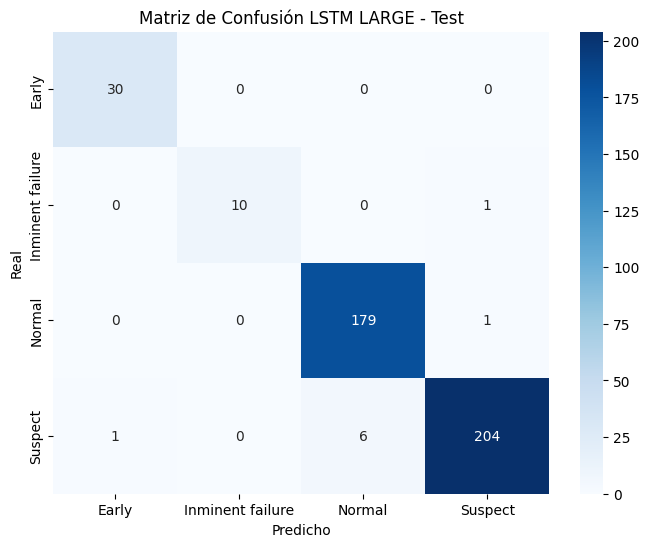

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM LARGE - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_lstm_large_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_lstm_large_test": wandb.Image(plt)})
    
plt.show()

### 2_test
Se empleo el dataset 2nd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [88]:
y_2nd_test_pred = best_model.predict(X_2nd_test)
y_2nd_test_pred = np.argmax(y_2nd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_2nd_test, y_2nd_test_pred))

print(classification_report(
    y_2nd_test,
    y_2nd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_2nd_test, y_2nd_test_pred, average='weighted')

    wandb.log({
        "2nd_test/precision": precision,
        "2nd_test/recall": recall,
        "2nd_test/f1_score": f1
    })

31/31 [==============================] - 0s 4ms/step
Accuracy: 0.5
                  precision    recall  f1-score   support

           Early       0.00      0.00      0.00        55
Inminent failure       0.19      0.86      0.31        14
          Normal       0.51      1.00      0.68       458
         Suspect       0.96      0.05      0.09       457

        accuracy                           0.50       984
       macro avg       0.41      0.48      0.27       984
    weighted avg       0.69      0.50      0.36       984



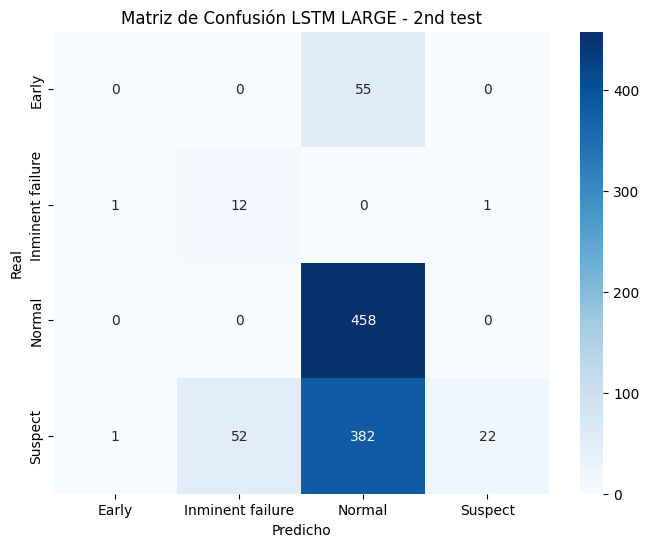

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_2nd_test, y_2nd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM LARGE - 2nd test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_lstm_large_2nd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_lstm_large_2nd_test": wandb.Image(plt)})
    
plt.show()

### 3rd_test
Se empleo el dataset 3rd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [90]:
y_3rd_test_pred = best_model.predict(X_3rd_test)
y_3rd_test_pred = np.argmax(y_3rd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_3rd_test, y_3rd_test_pred))

print(classification_report(
    y_3rd_test,
    y_3rd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_3rd_test, y_3rd_test_pred, average='weighted')

    wandb.log({
        "3rd_test/precision": precision,
        "3rd_test/recall": recall,
        "3rd_test/f1_score": f1
    })

198/198 [==============================] - 1s 3ms/step
Accuracy: 0.7084123972169513
                  precision    recall  f1-score   support

           Early       0.00      0.00      0.00       476
Inminent failure       0.79      0.98      0.87       131
          Normal       0.89      0.79      0.84      5376
         Suspect       0.07      0.28      0.11       341

        accuracy                           0.71      6324
       macro avg       0.44      0.51      0.46      6324
    weighted avg       0.78      0.71      0.74      6324



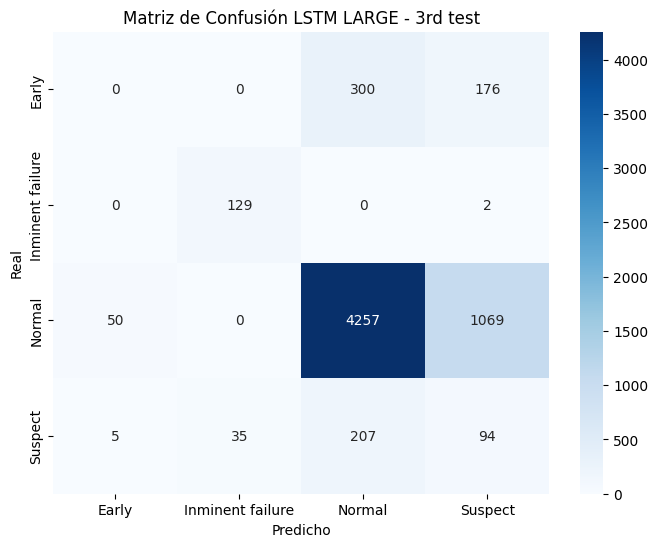

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_3rd_test, y_3rd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM LARGE - 3rd test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_lstm_large_3rd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_lstm_large_3rd_test": wandb.Image(plt)})
    
plt.show()

In [92]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

2nd_test/f1_score,▁
2nd_test/precision,▁
2nd_test/recall,▁
3rd_test/f1_score,▁
3rd_test/precision,▁
3rd_test/recall,▁
epoch/accuracy,▁▅▆▆▇▇▇▆▇▇▇▇▇████████▇██
epoch/epoch,▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇██
epoch/f1_score,▁▅▆▆▇▇▇▆▇▇▇█▇████▇███▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+10,...


# LSTM (GRU) - large
se duplico los tamaño de las capa con respecto al LSMT - base y se reemplazaron las capas de celdas LSTM por celdas GRU, esta arquitetura fue vista en [aca](https://arxiv.org/abs/1412.3555)

por lo que he probado hasta ahora tarda mucho en entrenar y no performa bien :(
    

In [93]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense

def make_build_model(X_train, num_classes):
    def build_model(hp):
        model = Sequential([

            # Primera capa GRU (Rango de 128 a 1024)
            GRU(
                units=hp.Int('gru_units_1', min_value=128, max_value=1024, step=128),
                return_sequences=True,
                activation='tanh',
                recurrent_activation='sigmoid',
                input_shape=(X_train.shape[1], X_train.shape[2])
            ),

            # Dropout para prevenir overfitting
            Dropout(
                rate=hp.Float('dropout_1', min_value=0.1, max_value=0.6, step=0.1)
            ),

            # Segunda capa GRU (Rango de 64 a 512)
            # return_sequences=False por defecto para aplanar la salida hacia la capa Densa
            GRU(
                units=hp.Int('gru_units_2', min_value=64, max_value=512, step=64),
                activation='tanh',
                recurrent_activation='sigmoid'
            ),

            # Capa Densa para procesamiento intermedio de características
            Dense(
                units=hp.Int('dense_units', min_value=128, max_value=1024, step=128),
                activation="relu"
            ),

            # Capa de salida para clasificación multiclase
            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy", F1MacroScore(num_classes=num_classes)]
        )

        return model
    return build_model

# eval_metric = "val_f1_score"  
eval_metric = "recall" 

tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective(eval_metric, direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='lstm_vibraciones'
)

stop_early_monitor = 'val_loss'  
stop_early = tf.keras.callbacks.EarlyStopping(monitor=stop_early_monitor, patience=5)

# Búsqueda de hiperparámetros
tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  lstm_units_1: {best_hps.get('lstm_units_1')}
  lstm_units_2: {best_hps.get('lstm_units_2')}
  dropout:      {best_hps.get('dropout_1')}
  dense_units:  {best_hps.get('dense_units')}
  lr:           {best_hps.get('lr')}
""")

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in best_hps.values.items()}
    config_params["param_metrica_evaluacion"] = eval_metric
    config_params["param_metrica_monitoreo"] = stop_early_monitor
    config_params["param_stop_early_monitor"] = stop_early_monitor


Reloading Tuner from kt_results/lstm_vibraciones/tuner0.json
Results summary
Results in kt_results/lstm_vibraciones
Showing 10 best trials
Objective(name="recall", direction="max")

Trial 0086 summary
Hyperparameters:
lstm_units_1: 32
dropout_1: 0.4
lstm_units_2: 80
dense_units: 128
lr: 0.008326380697068002
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.957563042640686

Trial 0083 summary
Hyperparameters:
lstm_units_1: 128
dropout_1: 0.1
lstm_units_2: 128
dense_units: 224
lr: 0.0005167397035568562
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0074
Score: 0.9575486779212952

Trial 0084 summary
Hyperparameters:
lstm_units_1: 224
dropout_1: 0.5
lstm_units_2: 16
dense_units: 160
lr: 0.003687492934224323
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0076
Score: 0.9575390219688416

Trial 0082 summary
Hyperparameters:
lstm_units_1: 128
dropout_1: 0.1
lstm_units_2: 128
dense_

In [94]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones_comparacion2",
        name=f"GRU_agregados_v6_{timestap_str}",
        tags=["gru", "large" ],
        config={**config_params, **config_params_dataset}
    )
    wandb.log_artifact(dataset_artifact)
    wandb.log_artifact(figures_artifact)

In [95]:
# Entrenar el modelo final con los mejores hiperparámetros
callbacks_list = [stop_early]

if usar_wandb:
    callbacks_list.append(WandbMetricsLogger())
    callbacks_list.append(WandbModelCheckpoint(
    filepath=f"{dir_artifacts}/best_gru_model.keras", 
    monitor=stop_early_monitor, 
    save_best_only=True,
    load_weights_on_restart=False
))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    # validation_split=0.2,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks_list
)

Epoch 1/40
204/204 [==============================] - 8s 16ms/step - loss: 0.4612 - accuracy: 0.8437 - f1_score: 0.8454 - val_loss: 0.3144 - val_accuracy: 0.8843 - val_f1_score: 0.8888
Epoch 2/40
204/204 [==============================] - 2s 10ms/step - loss: 0.2833 - accuracy: 0.8978 - f1_score: 0.9070 - val_loss: 0.2375 - val_accuracy: 0.9537 - val_f1_score: 0.9271
Epoch 3/40
204/204 [==============================] - 2s 11ms/step - loss: 0.2501 - accuracy: 0.9132 - f1_score: 0.9196 - val_loss: 0.1337 - val_accuracy: 0.9815 - val_f1_score: 0.9718
Epoch 4/40
204/204 [==============================] - 2s 10ms/step - loss: 0.2062 - accuracy: 0.9317 - f1_score: 0.9330 - val_loss: 0.1208 - val_accuracy: 0.9630 - val_f1_score: 0.9580
Epoch 5/40
204/204 [==============================] - 2s 10ms/step - loss: 0.1790 - accuracy: 0.9311 - f1_score: 0.9307 - val_loss: 0.1222 - val_accuracy: 0.9630 - val_f1_score: 0.9258
Epoch 6/40
204/204 [==============================] - 2s 12ms/step - loss: 

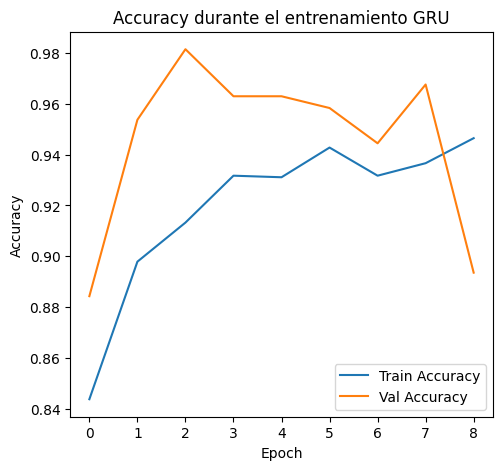

In [96]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento GRU')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_gru.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_gru_validacion": wandb.Image(plt)})
    
plt.legend()

In [97]:
# guardar el modelo entrenado 
best_model.save(f"{dir_artifacts}/best_gru_model.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [98]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 1s 4ms/step
Accuracy: 0.8935185185185185
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.60      1.00      0.75         6
          Normal       0.99      0.80      0.88        90
         Suspect       0.85      0.95      0.90       105

        accuracy                           0.89       216
       macro avg       0.86      0.94      0.88       216
    weighted avg       0.91      0.89      0.89       216



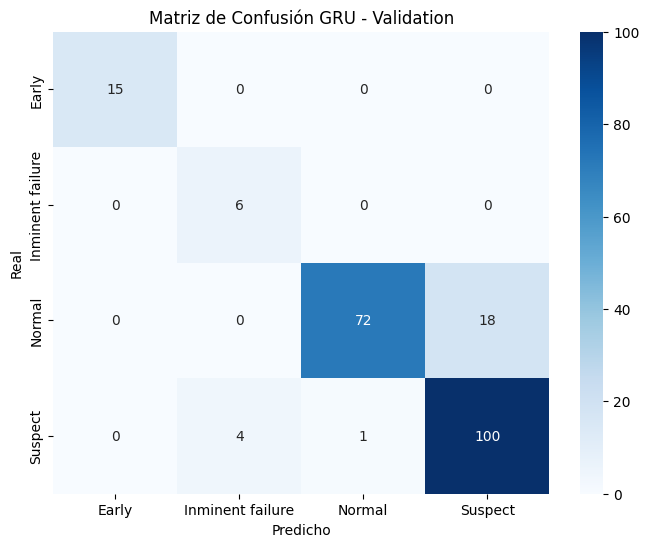

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión GRU - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_gru_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_gru_validation": wandb.Image(plt)})
    
plt.show()

## Evaluación - Test

### 1st_test (subconjunto 10%)
Se empleo el subconjunto 10% del dataset empleado para el entrenamiento

In [100]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 4ms/step
Accuracy: 0.9189814814814815
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.65      1.00      0.79        11
          Normal       0.99      0.85      0.92       180
         Suspect       0.88      0.96      0.92       211

        accuracy                           0.92       432
       macro avg       0.87      0.95      0.90       432
    weighted avg       0.93      0.92      0.92       432



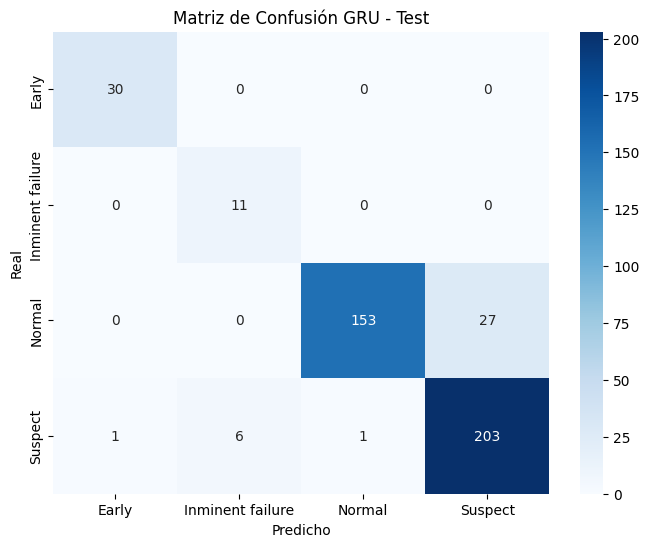

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión GRU - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_gru_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_gru_test": wandb.Image(plt)})
    
plt.show()

### 2_test
Se empleo el dataset 2nd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [102]:
y_2nd_test_pred = best_model.predict(X_2nd_test)
y_2nd_test_pred = np.argmax(y_2nd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_2nd_test, y_2nd_test_pred))

print(classification_report(
    y_2nd_test,
    y_2nd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_2nd_test, y_2nd_test_pred, average='weighted')

    wandb.log({
        "2nd_test/precision": precision,
        "2nd_test/recall": recall,
        "2nd_test/f1_score": f1
    })

31/31 [==============================] - 0s 4ms/step
Accuracy: 0.516260162601626
                  precision    recall  f1-score   support

           Early       0.00      0.00      0.00        55
Inminent failure       0.07      0.86      0.13        14
          Normal       0.59      1.00      0.74       458
         Suspect       0.97      0.08      0.15       457

        accuracy                           0.52       984
       macro avg       0.41      0.49      0.26       984
    weighted avg       0.73      0.52      0.42       984



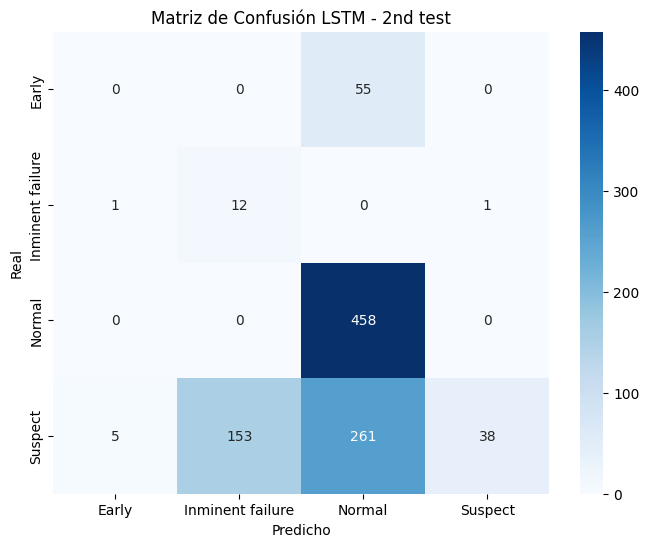

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_2nd_test, y_2nd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM - 2nd test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_gru_2nd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_gru_2nd_test": wandb.Image(plt)})
    
plt.show()

### 3rd_test
Se empleo el dataset 3rd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [104]:
y_3rd_test_pred = best_model.predict(X_3rd_test)
y_3rd_test_pred = np.argmax(y_3rd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_3rd_test, y_3rd_test_pred))

print(classification_report(
    y_3rd_test,
    y_3rd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_3rd_test, y_3rd_test_pred, average='weighted')

    wandb.log({
        "3rd_test/precision": precision,
        "3rd_test/recall": recall,
        "3rd_test/f1_score": f1
    })

198/198 [==============================] - 1s 3ms/step
Accuracy: 0.3034471853257432
                  precision    recall  f1-score   support

           Early       0.08      0.00      0.01       476
Inminent failure       0.09      0.89      0.16       131
          Normal       0.83      0.32      0.46      5376
         Suspect       0.03      0.29      0.06       341

        accuracy                           0.30      6324
       macro avg       0.26      0.38      0.17      6324
    weighted avg       0.71      0.30      0.40      6324



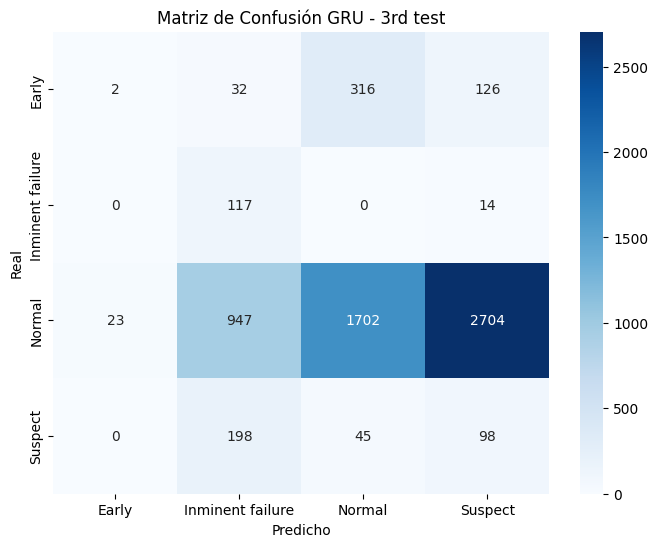

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_3rd_test, y_3rd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión GRU - 3rd test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_gru_3rd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_gru_3rd_test": wandb.Image(plt)})
    
plt.show()

In [106]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

2nd_test/f1_score,▁
2nd_test/precision,▁
2nd_test/recall,▁
3rd_test/f1_score,▁
3rd_test/precision,▁
3rd_test/recall,▁
epoch/accuracy,▁▅▆▇▇█▇▇█
epoch/epoch,▁▂▃▄▅▅▆▇█
epoch/f1_score,▁▅▆▇▇█▆▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁
+10,...


# XLSTM

In [ ]:
def make_build_model(X_train, num_classes):
    def build_model(hp):
        model = Sequential([

            # Primera capa xLSTM con búsqueda de espacio dimensional
            XLSTM(
                units=hp.Int('xlstm_units_1', min_value=32, max_value=256, step=32),
                return_sequences=True,  # Pasa las secuencias a la siguiente capa
                input_shape=(X_train.shape[1], X_train.shape[2])
            ),

            # Ajuste de Dropout dinámico
            Dropout(
                rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
            ),

            # Segunda capa xLSTM (Procesa la secuencia y devuelve la última salida funcional)
            XLSTM(
                units=hp.Int('xlstm_units_2', min_value=16, max_value=128, step=16),
                return_sequences=False
            ),

            # Capa de abstracción Dense adaptada a relu
            Dense(
                units=hp.Int('dense_units', min_value=32, max_value=256, step=32),
                activation="relu"
            ),

            # Clasificador final multiclase
            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=[
                "accuracy",
                SparseRecallMacro(num_classes=num_classes), 
                F1MacroScore(num_classes=num_classes)
            ]
        )

        return model
    return build_model

# eval_metric = "val_f1_score"  
eval_metric = "recall_macro" 

tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective(eval_metric, direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='xlstm_vibraciones'
)

stop_early_monitor = 'val_loss'  
stop_early = tf.keras.callbacks.EarlyStopping(monitor=stop_early_monitor, patience=5)

# Búsqueda de hiperparámetros
tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  xlstm_units_1: {best_hps.get('xlstm_units_1')}
  xlstm_units_2: {best_hps.get('xlstm_units_2')}
  dropout:      {best_hps.get('dropout_1')}
  dense_units:  {best_hps.get('dense_units')}
  lr:           {best_hps.get('lr')}
""")

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in best_hps.values.items()}
    config_params["param_metrica_evaluacion"] = eval_metric
    config_params["param_metrica_monitoreo"] = stop_early_monitor
    config_params["param_stop_early_monitor"] = stop_early_monitor


Trial 90 Complete [00h 01m 27s]
recall_macro: 0.9238461256027222

Best recall_macro So Far: 0.9353846311569214
Total elapsed time: 00h 29m 19s
Results summary
Results in kt_results/xlstm_vibraciones
Showing 10 best trials
Objective(name="recall_macro", direction="max")

Trial 0051 summary
Hyperparameters:
xlstm_units_1: 32
dropout_1: 0.30000000000000004
xlstm_units_2: 96
dense_units: 32
lr: 0.002998003302664412
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 3
tuner/round: 3
tuner/trial_id: 0048
Score: 0.9353846311569214

Trial 0082 summary
Hyperparameters:
xlstm_units_1: 256
dropout_1: 0.2
xlstm_units_2: 128
dense_units: 160
lr: 0.0014917371644323784
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0074
Score: 0.9353846311569214

Trial 0085 summary
Hyperparameters:
xlstm_units_1: 224
dropout_1: 0.2
xlstm_units_2: 32
dense_units: 160
lr: 0.0006034416622484507
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0

KeyError: 'lstm_units_1 does not exist.'

In [76]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones_comparacion2",
        name=f"XLSTM_agregados_v6_{timestap_str}",
        tags=["xlstm", "hyperparameter_tuning", "recall_macro"],
        config={**config_params, **config_params_dataset}
    )
    wandb.log_artifact(dataset_artifact)
    wandb.log_artifact(figures_artifact)

In [77]:
# Entrenar el modelo final con los mejores hiperparámetros
callbacks_list = [stop_early]

if usar_wandb:
    callbacks_list.append(WandbMetricsLogger())
    callbacks_list.append(WandbModelCheckpoint(
    filepath=f"{dir_artifacts}/best_xlstm_model.keras", 
    monitor=stop_early_monitor, 
    save_best_only=True,
    load_weights_on_restart=False
))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    # validation_split=0.2,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks_list
)

Epoch 1/40
200/204 [============================>.] - ETA: 0s - loss: 0.6678 - accuracy: 0.6637 - recall_macro: 0.6637 - f1_score: 0.7257

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:2723: UserWarning: Metric SparseRecallMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


204/204 [==============================] - 10s 17ms/step - loss: 0.6657 - accuracy: 0.6671 - recall_macro: 0.6671 - f1_score: 0.7279 - val_loss: 0.4174 - val_accuracy: 0.8519 - val_recall_macro: 0.8519 - val_f1_score: 0.8708
Epoch 2/40
204/204 [==============================] - 2s 10ms/step - loss: 0.4092 - accuracy: 0.8320 - recall_macro: 0.8320 - f1_score: 0.8584 - val_loss: 0.3563 - val_accuracy: 0.8565 - val_recall_macro: 0.8565 - val_f1_score: 0.8811
Epoch 3/40
204/204 [==============================] - 2s 9ms/step - loss: 0.3703 - accuracy: 0.8480 - recall_macro: 0.8480 - f1_score: 0.8690 - val_loss: 0.3913 - val_accuracy: 0.8102 - val_recall_macro: 0.8102 - val_f1_score: 0.8279
Epoch 4/40
204/204 [==============================] - 2s 10ms/step - loss: 0.3630 - accuracy: 0.8498 - recall_macro: 0.8498 - f1_score: 0.8748 - val_loss: 0.3767 - val_accuracy: 0.8241 - val_recall_macro: 0.8241 - val_f1_score: 0.8052
Epoch 5/40
204/204 [==============================] - 2s 10ms/step - lo

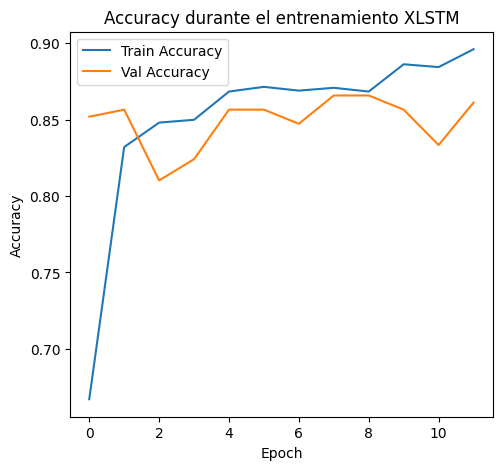

In [78]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento XLSTM')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_xlstm.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_xlstm_validacion": wandb.Image(plt)})
    
plt.legend()

In [79]:
# guardar el modelo entrenado 
best_model.save(f"{dir_artifacts}/best_xlstm_model.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [80]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 1s 4ms/step
Accuracy: 0.8611111111111112
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.83      0.83      0.83         6
          Normal       0.84      0.86      0.85        90
         Suspect       0.86      0.85      0.86       105

        accuracy                           0.86       216
       macro avg       0.88      0.88      0.88       216
    weighted avg       0.86      0.86      0.86       216



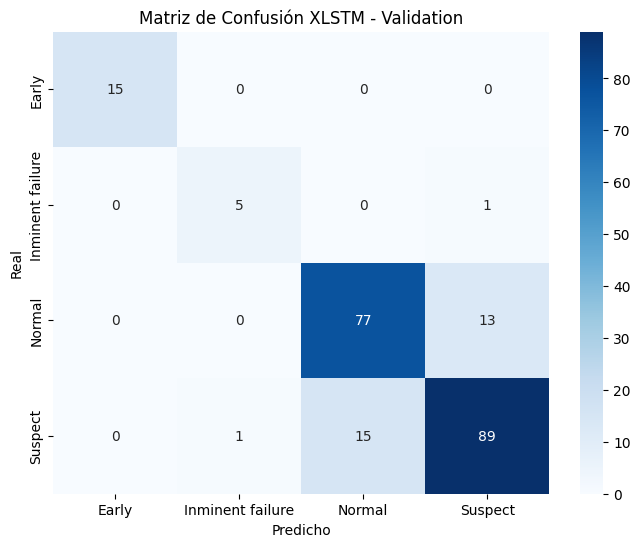

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión XLSTM - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_xlstm_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_xlstm_validation": wandb.Image(plt)})
    
plt.show()

## Evaluación - Test

### 1st_test (subconjunto 10%)
Se empleo el subconjunto 10% del dataset empleado para el entrenamiento

In [82]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 4ms/step
Accuracy: 0.8564814814814815
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.60      0.82      0.69        11
          Normal       0.84      0.87      0.85       180
         Suspect       0.87      0.83      0.85       211

        accuracy                           0.86       432
       macro avg       0.82      0.88      0.85       432
    weighted avg       0.86      0.86      0.86       432



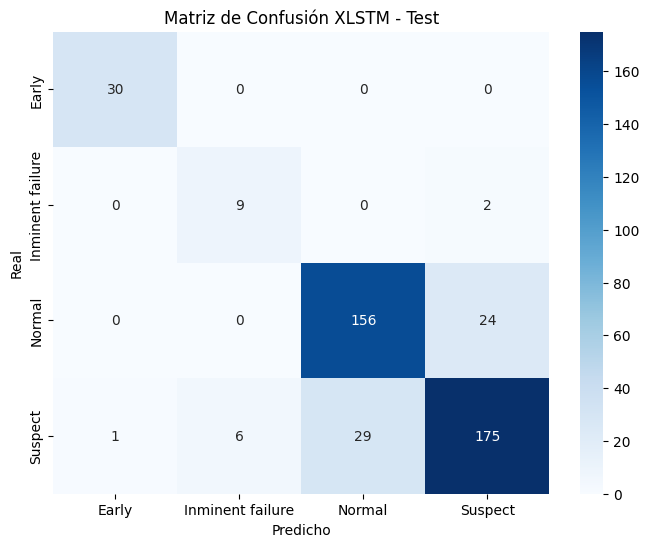

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión XLSTM - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_xlstm_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_xlstm_test": wandb.Image(plt)})
    
plt.show()

### 2_test
Se empleo el dataset 2nd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [84]:
y_2nd_test_pred = best_model.predict(X_2nd_test)
y_2nd_test_pred = np.argmax(y_2nd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_2nd_test, y_2nd_test_pred))

print(classification_report(
    y_2nd_test,
    y_2nd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_2nd_test, y_2nd_test_pred, average='weighted')

    wandb.log({
        "2nd_test/precision": precision,
        "2nd_test/recall": recall,
        "2nd_test/f1_score": f1
    })

31/31 [==============================] - 0s 3ms/step
Accuracy: 0.3170731707317073
                  precision    recall  f1-score   support

           Early       0.06      0.22      0.09        55
Inminent failure       0.04      0.79      0.08        14
          Normal       0.69      0.37      0.48       458
         Suspect       0.43      0.26      0.33       457

        accuracy                           0.32       984
       macro avg       0.31      0.41      0.25       984
    weighted avg       0.52      0.32      0.38       984



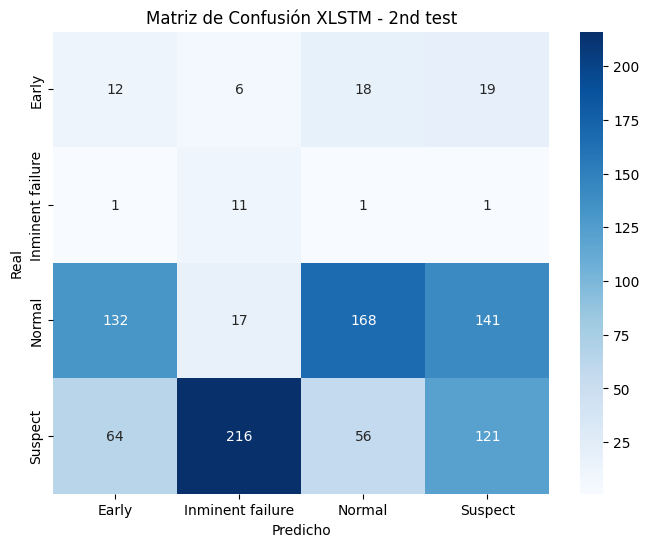

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_2nd_test, y_2nd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión XLSTM - 2nd test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_xlstm_2nd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_xlstm_2nd_test": wandb.Image(plt)})
    
plt.show()

### 3rd_test
Se empleo el dataset 3rd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [86]:
y_3rd_test_pred = best_model.predict(X_3rd_test)
y_3rd_test_pred = np.argmax(y_3rd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_3rd_test, y_3rd_test_pred))

print(classification_report(
    y_3rd_test,
    y_3rd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_3rd_test, y_3rd_test_pred, average='weighted')

    wandb.log({
        "3rd_test/precision": precision,
        "3rd_test/recall": recall,
        "3rd_test/f1_score": f1
    })

198/198 [==============================] - 1s 3ms/step
Accuracy: 0.5069576217583808
                  precision    recall  f1-score   support

           Early       0.01      0.00      0.00       476
Inminent failure       0.04      0.88      0.08       131
          Normal       0.95      0.57      0.71      5376
         Suspect       0.11      0.12      0.11       341

        accuracy                           0.51      6324
       macro avg       0.28      0.39      0.23      6324
    weighted avg       0.81      0.51      0.61      6324



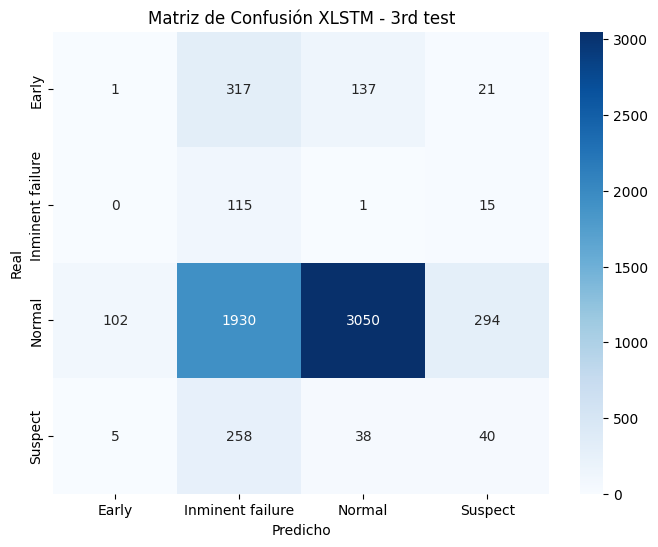

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_3rd_test, y_3rd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión XLSTM - 3rd test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_xlstm_3rd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_xlstm_3rd_test": wandb.Image(plt)})
    
plt.show()

In [88]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

2nd_test/f1_score,▁
2nd_test/precision,▁
2nd_test/recall,▁
3rd_test/f1_score,▁
3rd_test/precision,▁
3rd_test/recall,▁
epoch/accuracy,▁▆▇▇▇▇▇▇▇███
epoch/epoch,▁▂▂▃▄▄▅▅▆▇▇█
epoch/f1_score,▁▆▆▆▇▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁
+12,...
